
# Building sector archetype model tutorial

This notebook is a practical guide for using the `BuildingSector` model in `model.py`.

The student task is to create or edit constraints in `constraints_sector_model.xlsx`, solve a synthetic building-sector model, and analyse the resulting model properties:

- net floor area (NFA) by archetype
- final energy demand and useful energy indicators
- CO₂-related indicators, if available in the archetype table
- distributions by building use, construction period, size class, building quality, and energy supply system

The notebook is intentionally explicit. Most cells show the functionality directly instead of hiding it in helper functions. A helper function is only introduced when the same code is useful several times.



## Notebook outline

1. Load packages and `model.py`
2. Load the archetype table and the constraints workbook
3. Inspect the two main constraint sheets: `NGF` and `EE`
4. Understand how Excel rows become optimization constraints
5. Add NGF constraints
6. Add EE constraints
7. Solve the model
8. Inspect results and slack variables
9. Analyse energy and CO₂ indicators
10. Plot distributions with pandas and seaborn
11. Redo constraints after editing Excel
12. Compare simple model variants
13. Export results



## 1. Setup

`model.py` contains the actual optimization wrapper.

Important classes:

- `BuildingSector`: stores archetypes, constraints, the PuLP model, and result helpers
- `Constraint`: stores one model constraint
- `is_empty`: treats empty Excel cells as “no filter” or “no target column”

The model has one decision variable per archetype:


$NFA_i \geq 0$


The decision variable means: **how much net floor area of archetype `i` occurs in the modeled building sector**.


In [2]:

import sys
from pathlib import Path
import inspect

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Autoreload is useful while developing model.py.
# It reloads imported modules automatically when the source file changes.
# IPython magic commands: https://ipython.readthedocs.io/en/stable/interactive/magics.html
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except Exception:
    pass

# Make model.py importable if it is stored next to this notebook.
# sys.path is Python's list of import search locations:
# https://docs.python.org/3/library/sys.html#sys.path
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from archifer.model import BuildingSector, Constraint, is_empty

sns.set_theme(style="whitegrid")



## 2. Configure file paths

The intended project structure is usually:

```text
project/
├─ notebooks/
│  └─ building_sector_model_tutorial.ipynb
├─ data/
│  ├─ building_stock_archetypes.xlsx
│  └─ constraints_sector_model.xlsx
└─ src/
   └─ archifer/
      ├─ __init__.py (empty)
      └─ model.py
```

The code below searches a few common locations. This keeps the notebook usable if it is run from the project root or from a notebook folder.


In [3]:

# A Python list stores several values in a fixed order:
# https://docs.python.org/3/tutorial/introduction.html#lists
possible_data_dirs = [
    Path("data"),
    Path("../data"),
    Path("."),
]

DATA_DIR = None

# A for-loop repeats the same check for every candidate folder:
# https://docs.python.org/3/tutorial/controlflow.html#for-statements
for folder in possible_data_dirs:
    if (folder / "constraints_sector_model.xlsx").exists():
        DATA_DIR = folder
        break

if DATA_DIR is None:
    raise FileNotFoundError("Could not find constraints_sector_model.xlsx in data/, ../data/, or ./")

ARCHETYPE_PATH = DATA_DIR / "building_stock_archetypes.xlsx"
CONSTRAINTS_PATH = DATA_DIR / "constraints_sector_model.xlsx"

print("DATA_DIR:", DATA_DIR.resolve())
print("ARCHETYPE_PATH:", ARCHETYPE_PATH.resolve())
print("CONSTRAINTS_PATH:", CONSTRAINTS_PATH.resolve())


DATA_DIR: C:\Users\schneids\code\building-archetype-inference\data
ARCHETYPE_PATH: C:\Users\schneids\code\building-archetype-inference\data\building_stock_archetypes.xlsx
CONSTRAINTS_PATH: C:\Users\schneids\code\building-archetype-inference\data\constraints_sector_model.xlsx


In [4]:

# Fail early with a readable error if the archetype workbook is missing.
if not ARCHETYPE_PATH.exists():
    raise FileNotFoundError(
        f"Archetype file not found: {ARCHETYPE_PATH}\n"
        "Place building_stock_archetypes.xlsx in the same data folder."
    )



## 3. Load archetypes and constraints

The constraints workbook currently contains several sheets. In this tutorial, the two main sheets are:

- `NGF`: net floor area constraints
- `EE`: end-energy constraints

The `NGF` sheet contains statistical NFA targets by use, size class, and construction period.  
The `EE` sheet contains total energy targets. Some rows are filtered by energy supply; rows with an empty energy-supply cell apply to all matching archetypes.


In [5]:

# pd.ExcelFile lets us inspect sheet names before reading individual sheets.
constraints_workbook = pd.ExcelFile(CONSTRAINTS_PATH)
print(constraints_workbook.sheet_names)


['constraints', 'NGF_simplified', 'NGF', 'geometry', 'EE', 'renovation']


In [6]:

archetype_df = pd.read_excel(ARCHETYPE_PATH, index_col=0)
ngf_constraints_df = pd.read_excel(CONSTRAINTS_PATH, sheet_name="NGF")
ee_constraints_df = pd.read_excel(CONSTRAINTS_PATH, sheet_name="EE")

print("Archetypes:", archetype_df.shape)
print("NGF constraints:", ngf_constraints_df.shape)
print("EE constraints:", ee_constraints_df.shape)


Archetypes: (2898, 519)
NGF constraints: (900, 13)
EE constraints: (8, 6)


In [7]:

# Show the first rows of the two sheets that students will edit most often.
display(ngf_constraints_df)
display(ee_constraints_df.head(10))


,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,target_column,target_value,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,983229,NaN,NaN,Zusammen,Andere Gebäude,bis 1978,179440026.0
1,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,391933,NaN,NaN,Zusammen,Andere Gebäude,1979 - 2009,120106016.0
2,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,594234,NaN,NaN,Zusammen,Andere Gebäude,2010 - 2030,29680973.0
3,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,629490,NaN,NaN,Zusammen,Wohngebäude,bis 1944,99641747.0
4,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,634503,NaN,NaN,Zusammen,Wohngebäude,1945 - 1989,227405833.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,1945 - 1989,NaN,5451357,NaN,NaN,NaN,NaN,NaN,NaN
896,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,1945 - 1989,NaN,3794303,NaN,NaN,NaN,NaN,NaN,NaN
897,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,1990 - 1999,NaN,3135980,NaN,NaN,NaN,NaN,NaN,NaN
898,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,2000 - 2020,NaN,4900876,NaN,NaN,NaN,NaN,NaN,NaN


,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Energy Supply,target_column,target_value
0,2021,Zusammen,Wohngebäude,NaN,Gas_Quartier_kWh/m²NGFa,1.703739e+10
1,2021,Zusammen,Wohngebäude,NaN,Biomasse_Quartier_kWh/m²NGFa,1.972013e+10
2,2021,Zusammen,Wohngebäude,NaN,Fernwärme_Quartier_kWh/m²NGFa,9.715264e+09
3,2021,Zusammen,Wohngebäude,NaN,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10
4,2021,Zusammen,Wohngebäude,Electricity (direct),Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09
5,2021,Zusammen,Wohngebäude,Heat Pump,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09
6,2021,Zusammen,Wohngebäude,NaN,Warmwasser_Endenergiebedarf_kWh/m²NGFa,1.073889e+10
7,2021,Zusammen,Wohngebäude,NaN,Heizen_Endenergiebedarf_kWh/m²NGFa,5.198375e+10



## 4. Inspect columns

Before modeling, check whether the constraint columns match the archetype columns.

The model can only filter by columns that exist in the archetype table.  
The model can only use `target_column` values that exist as numeric columns in the archetype table.


In [72]:
# Convert column names into a one-column dataframe for easier reading.
pd.DataFrame({"archetype_column": archetype_df.columns})


,archetype_column
0,Total Net floor Area
1,Gebäudeigenschaft (überwiegende Nutzung) (Eben...
2,Geometry
3,m²NGF
4,Nettogrundfläche in Quadratmetern (in Klassen)...
...,...
515,WW 1 Hilfsstrom__kWh/m²NGFa
516,WW 2 Endenergie thermisch__kWh/m²NGFa
517,WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__...
518,WW 2 Hilfsstrom__kWh/m²NGFa


In [9]:

print("NGF columns")
display(pd.DataFrame({"column": ngf_constraints_df.columns}))

print("EE columns")
display(pd.DataFrame({"column": ee_constraints_df.columns}))


NGF columns


,column
0,Jahr
1,Region – Gebietsstand 2023 (Ebene +2)
2,Gebäudeigenschaft (überwiegende Nutzung) (Eben...
3,Nettogrundfläche in Quadratmetern (in Klassen)...
4,Building Period
5,target_column
6,target_value
7,Unnamed: 7
8,Unnamed: 8
9,Unnamed: 9


EE columns


,column
0,Jahr
1,Region – Gebietsstand 2023 (Ebene +2)
2,Gebäudeigenschaft (überwiegende Nutzung) (Eben...
3,Energy Supply
4,target_column
5,target_value


In [10]:

# Show which archetype columns are referenced by the EE sheet.
# dropna() removes empty Excel cells.
ee_target_columns = ee_constraints_df["target_column"].dropna().drop_duplicates()
display(ee_target_columns.to_frame("EE target_column values"))

print("Missing EE target columns in archetype_df:")
for col in ee_target_columns:
    if col not in archetype_df.columns:
        print("-", col)


,EE target_column values
0,Gas_Quartier_kWh/m²NGFa
1,Biomasse_Quartier_kWh/m²NGFa
2,Fernwärme_Quartier_kWh/m²NGFa
3,Sonstige_Quartier_kWh/m²NGFa
4,Netzstrom_Heizen_kWh/m²NGFa
6,Warmwasser_Endenergiebedarf_kWh/m²NGFa
7,Heizen_Endenergiebedarf_kWh/m²NGFa


Missing EE target columns in archetype_df:


In [11]:

# Compact overview of columns that look categorical.
# nunique counts distinct values: https://pandas.pydata.org/docs/reference/api/pandas.Series.nunique.html
category_overview = []

for col in archetype_df.columns:
    n_unique = archetype_df[col].nunique(dropna=True)
    if archetype_df[col].dtype == "object" or n_unique <= 20:
        category_overview.append({"column": col, "n_unique": n_unique})

category_overview_df = pd.DataFrame(category_overview)
display(category_overview_df.sort_values("n_unique"))


,column,n_unique
0,Total Net floor Area,0
314,__69,0
319,__70,0
292,__67,0
293,__68,0
...,...,...
337,WW 1 Hilfsstrom__kWh/m²NGFa,12
334,WW Endenergiebedarf Thermisch__kWh/m²NGFa,12
335,WW Hilfsstrom__,12
136,#BEZUG!25,18


In [12]:

# Inspect selected categories if they exist.
# This helps students understand what values can be used in Excel filter columns.
candidate_category_cols = [
    "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
    "Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)",
    "Bauperiode (Ebene +2)",
    "Building Quality",
    "Geometry",
    "Energy Supply",
    "EnergySupply",
]

for col in candidate_category_cols:
    if col in archetype_df.columns:
        print("\n" + col)
        display(archetype_df[col].value_counts(dropna=False).to_frame("number of archetypes"))



Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)


,number of archetypes
Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),
Wohngebäude,2880
Andere Gebäude,18



Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)


,number of archetypes
Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),
Unter 200 Quadratmeter,966
300 bis 500 Quadratmeter,960
1000 Quadratmeter und mehr,960
300 bis unter 500 Quadratmeter,6
1 000 Quadratmeter und mehr,6



Bauperiode (Ebene +2)


...

,number of archetypes
Building Quality,
original,738
OIB_1/3,720
NEH_2/3,720
PH_3/3,720



Geometry


,number of archetypes
Geometry,
EFHo,480
EFHk,480
MFHo,480
MFHk,480
GWBk,480
GWBg,480
DLG1k,3
DLG1g,3
DLG2k,3



Energy Supply


,number of archetypes
Energy Supply,
Heat Pump,1440
Electricity (direct),480
Natural Gas,258
DH (CHP),240
Biomass,240
Oil,240



## 5. Constraint logic under the hood

For an absolute constraint, `model.py` creates this expression:

$\sum_i NFA_i \cdot x_i = target$


where:

- $`NFA_i`$ is the decision variable for archetype $`i`$
- $`x_i`$ is the selected archetype column, for example `kWh/m²NFA`
- $`target`$ is a total target from Excel, for example total kWh

If the Excel cell `target_column` is empty, then $`x_i = 1`$, so the constraint becomes:


$\sum_i NFA_i = target$


This is how the `NGF` sheet creates total NFA constraints.

All constraints are currently soft constraints. This means the model may violate them, but it pays a penalty via positive and negative slack variables.


In [13]:

# inspect.getsource prints the actual source code of a Python function:
# https://docs.python.org/3/library/inspect.html#inspect.getsource
print(inspect.getsource(BuildingSector._lhs_expr))
print(inspect.getsource(BuildingSector._apply_constraint))


    def _lhs_expr(self, ids, column):
        if column is None:
            return pl.lpSum(self.n[i] for i in ids)

        return pl.lpSum(self.n[i] * self.archetypes.at[i, column] for i in ids)

    def _apply_constraint(self, c:Constraint):

        filtered_ids = self._filter_indices(c.filter)
        if len(filtered_ids) == 0:
            print(f"Skipping {c.name}: no matching archetypes")
            return

        lhs = self._lhs_expr(filtered_ids, c.column)

        # elif c.type == "greater than target":
        #     s_neg = pl.LpVariable(f"s_{c.name}_shortfall", lowBound=0)
        #     self.model += (expr + s_neg >= c.target), c.name
        #     self.objective_terms.append(c.weight * s_neg)

        # elif c.type == "less than target":
        #     s_pos = pl.LpVariable(f"s_{c.name}_excess", lowBound=0)
        #     self.model += (expr - s_pos <= c.target), c.name
        #     self.objective_terms.append(c.weight * s_pos)

        if c.type == "absolute":
         


## 6. Define shared column names

The constraints workbook uses two central columns:

- `target_value`: numeric right-hand-side value
- `target_column`: archetype column used as multiplier

Examples:

| target_column | target_value | meaning |
|---|---:|---|
| empty | 1,000,000 | total NFA is 1,000,000 m² |
| `Heizen_Endenergiebedarf_kWh/m²NGFa` | 50,000,000 | total heating final energy is 50,000,000 kWh |
| `Gas_Quartier_kWh/m²NGFa` | 17,000,000,000 | total gas energy is 17,000,000,000 kWh |


In [14]:

TARGET_VALUE_COL = "target_value"
TARGET_COLUMN_COL = "target_column"

print("NGF target columns available:", TARGET_VALUE_COL in ngf_constraints_df.columns, TARGET_COLUMN_COL in ngf_constraints_df.columns)
print("EE target columns available:", TARGET_VALUE_COL in ee_constraints_df.columns, TARGET_COLUMN_COL in ee_constraints_df.columns)


NGF target columns available: True True
EE target columns available: True True



## 7. Define filter columns

A filter column selects a subset of archetypes.

For example, one `NGF` row may select:

- building use: `Wohngebäude`
- size class: `Unter 200 Quadratmeter`
- construction period: `Vor 1919`

If one of these cells is empty in Excel, the model does **not** apply that filter for that row.

This is important for the `EE` sheet: some rows have an empty `Energy Supply`, so they apply to all energy supply systems.


In [15]:

ngf_filter_cols = [
    "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
    "Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)",
    "Building Period",
]

# For EE, the constraints use building use and sometimes Energy Supply.
# If Energy Supply is empty in Excel, it is ignored for that row.
ee_filter_cols = [
    "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
    "Energy Supply",
]


In [16]:

# If the archetype table uses a slightly different spelling, use a mapping.
# A Python dictionary maps keys to values:
# https://docs.python.org/3/tutorial/datastructures.html#dictionaries
if "Energy Supply" not in archetype_df.columns and "EnergySupply" in archetype_df.columns:
    ee_filter_cols = {
        "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)": "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
        "Energy Supply": "EnergySupply",
    }

print("NGF filter columns:", ngf_filter_cols)
print("EE filter columns:", ee_filter_cols)


NGF filter columns: ['Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)', 'Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)', 'Building Period']
EE filter columns: ['Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)', 'Energy Supply']



## 8. Validate the constraint sheets

The following cells do simple checks before solving. They are intentionally direct and readable.


In [17]:

# Check that NGF filter columns exist in both dataframes.
for col in ngf_filter_cols:
    if col not in ngf_constraints_df.columns:
        print("Missing in NGF constraints:", col)
    if col not in archetype_df.columns:
        print("Missing in archetypes:", col)

for col in [TARGET_VALUE_COL, TARGET_COLUMN_COL]:
    if col not in ngf_constraints_df.columns:
        print("Missing in NGF constraints:", col)


In [18]:

# Check EE filter columns.
if isinstance(ee_filter_cols, dict):
    ee_filter_pairs = list(ee_filter_cols.items())
else:
    ee_filter_pairs = [(col, col) for col in ee_filter_cols]

for constraint_col, archetype_col in ee_filter_pairs:
    if constraint_col not in ee_constraints_df.columns:
        print("Missing in EE constraints:", constraint_col)
    if archetype_col not in archetype_df.columns:
        print("Missing in archetypes:", archetype_col)

for col in [TARGET_VALUE_COL, TARGET_COLUMN_COL]:
    if col not in ee_constraints_df.columns:
        print("Missing in EE constraints:", col)


In [19]:

# Check whether every non-empty target_column value points to an archetype column.
for col in ee_constraints_df[TARGET_COLUMN_COL].dropna().drop_duplicates():
    if col not in archetype_df.columns:
        print("EE target_column not found in archetype table:", col)



## 9. Build a model with NGF and EE constraints

We now create one `BuildingSector` object.

The constraint definitions are stored in `bs.constraints`.  
The PuLP model itself is rebuilt fresh every time `bs.solve()` is called.


In [74]:

bs = BuildingSector(archetype_df)

print("Number of archetypes:", len(bs.ids))
print("Number of constraints before adding Excel rows:", len(bs.constraints))


Number of archetypes: 2898
Number of constraints before adding Excel rows: 0


In [76]:
ngf_constraints_df

,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,target_column,target_value,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,983229,NaN,NaN,Zusammen,Andere Gebäude,bis 1978,179440026.0
1,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,391933,NaN,NaN,Zusammen,Andere Gebäude,1979 - 2009,120106016.0
2,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,594234,NaN,NaN,Zusammen,Andere Gebäude,2010 - 2030,29680973.0
3,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,629490,NaN,NaN,Zusammen,Wohngebäude,bis 1944,99641747.0
4,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,634503,NaN,NaN,Zusammen,Wohngebäude,1945 - 1989,227405833.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,1945 - 1989,NaN,5451357,NaN,NaN,NaN,NaN,NaN,NaN
896,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,1945 - 1989,NaN,3794303,NaN,NaN,NaN,NaN,NaN,NaN
897,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,1990 - 1999,NaN,3135980,NaN,NaN,NaN,NaN,NaN,NaN
898,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,2000 - 2020,NaN,4900876,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:

# Weight controls how expensive one unit of constraint violation is.
# NGF constraints usually define the main statistical structure of the sector.
WEIGHT_NGF = 1_000_000

bs.add_constraints_from_df(
    constraints_df=ngf_constraints_df,
    filter_cols=ngf_filter_cols,
    target="target_value",
    target_column_col="target_column",
    weight=WEIGHT_NGF,
    name_prefix="Stat_AT_NGF",
)

print("Number of constraints after NGF:", len(bs.constraints))
display(bs.list_constraints().head())


Number of constraints after NGF: 900


,name,type,filter,column,target,weight
0,Stat_AT_NGF_0,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,983229.0,1000000
1,Stat_AT_NGF_1,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,391933.0,1000000
2,Stat_AT_NGF_2,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,594234.0,1000000
3,Stat_AT_NGF_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,629490.0,1000000
4,Stat_AT_NGF_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,634503.0,1000000


In [22]:

# EE constraints are energy totals. Their targets are very large numbers in kWh.
# Therefore the weight does not need to be as high as for NGF.
WEIGHT_EE = 1

bs.add_constraints_from_df(
    constraints_df=ee_constraints_df,
    filter_cols=ee_filter_cols,
    target=TARGET_VALUE_COL,
    target_column_col=TARGET_COLUMN_COL,
    weight=WEIGHT_EE,
    name_prefix="EE",
)

print("Number of constraints after NGF + EE:", len(bs.constraints))
display(bs.list_constraints().tail(12))


Number of constraints after NGF + EE: 908


,name,type,filter,column,target,weight
896,Stat_AT_NGF_896,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,3.794303e+06,1000000
897,Stat_AT_NGF_897,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,3.135980e+06,1000000
898,Stat_AT_NGF_898,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,4.900876e+06,1000000
899,Stat_AT_NGF_899,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,1.116581e+07,1000000
900,EE_0,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Gas_Quartier_kWh/m²NGFa,1.703739e+10,1
901,EE_1,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Biomasse_Quartier_kWh/m²NGFa,1.972013e+10,1
902,EE_2,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Fernwärme_Quartier_kWh/m²NGFa,9.715264e+09,1
903,EE_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10,1
904,EE_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09,1
905,EE_5,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09,1



## 10. Solve the optimization model

`timeLimit` is the maximum solver time in seconds. For teaching and exploration, a short time limit is useful. For a final run, increase it or remove it in `model.py`.


In [23]:

nfa_result = bs.solve(timeLimit=10)

# The returned series contains the optimized NFA per archetype.
display(nfa_result.head())


Skipping Stat_AT_NGF_9: no matching archetypes
Skipping Stat_AT_NGF_10: no matching archetypes
Skipping Stat_AT_NGF_11: no matching archetypes
Skipping Stat_AT_NGF_12: no matching archetypes
Skipping Stat_AT_NGF_13: no matching archetypes
Skipping Stat_AT_NGF_14: no matching archetypes
Skipping Stat_AT_NGF_15: no matching archetypes
Skipping Stat_AT_NGF_16: no matching archetypes
Skipping Stat_AT_NGF_17: no matching archetypes
Skipping Stat_AT_NGF_27: no matching archetypes
Skipping Stat_AT_NGF_28: no matching archetypes
Skipping Stat_AT_NGF_29: no matching archetypes
Skipping Stat_AT_NGF_30: no matching archetypes
Skipping Stat_AT_NGF_31: no matching archetypes
Skipping Stat_AT_NGF_32: no matching archetypes
Skipping Stat_AT_NGF_33: no matching archetypes
Skipping Stat_AT_NGF_34: no matching archetypes
Skipping Stat_AT_NGF_35: no matching archetypes
Skipping Stat_AT_NGF_54: no matching archetypes
Skipping Stat_AT_NGF_55: no matching archetypes
Skipping Stat_AT_NGF_56: no matching arch

1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
dtype: float64

## Get the result dataframe

`result_df()` returns the original archetype table plus the optimized result column.

In this notebook, the result column is called `NFA`.

In [24]:

# result_df() returns the full archetype table plus the optimized NFA column.
result = bs.result_df(value_col="NFA")

print("Total optimized NFA:", result["NFA"].sum())
print(result.shape)
display(result.head())


Total optimized NFA: 2410775517.0
(2898, 521)


,Total Net floor Area,Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Geometry,m²NGF,Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,Bauperiode (Ebene +2),Building Quality,renovated,thermisch wirksame Speichermasse,...,WW Endenergiebedarf Elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW Hilfsstrom__,WW 1 Endenergie thermisch__kWh/m²NGFa,WW 1 Endenergie elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW 1 Hilfsstrom__kWh/m²NGFa,WW 2 Endenergie thermisch__kWh/m²NGFa,WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__kWh/m²NGFa,WW 2 Hilfsstrom__kWh/m²NGFa,buildings,NFA
ID,,,,,,,,,,,,,,,,,,,,,
1,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),...,0.79878,0.79878,15.97561,0.79878,0.79878,0,0,0,0.0,0.0
2,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,OIB_1/3,1,mittel (124 Wh/m²K),...,0.79878,0.79878,15.97561,0.79878,0.79878,0,0,0,0.0,0.0
3,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,NEH_2/3,1,mittel (124 Wh/m²K),...,0.79878,0.79878,15.97561,0.79878,0.79878,0,0,0,0.0,0.0
4,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,PH_3/3,1,mittel (124 Wh/m²K),...,0.79878,0.79878,15.97561,0.79878,0.79878,0,0,0,0.0,0.0
5,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),...,0.88753,0.88753,17.75061,0.88753,0.88753,0,0,0,0.0,0.0


In [25]:

# Keep only archetypes that occur in the solved model.
positive_result = result[result["NFA"] > 0].copy()

print("Number of selected archetypes:", len(positive_result))
display(positive_result[["NFA"]].head())


Number of selected archetypes: 31


,NFA
ID,
140,134942250.0
141,24491579.0
166,1.0
283,928045000.0
321,1947727.0



## 11. Basic result plot

`model.py` already contains a simple horizontal bar chart.


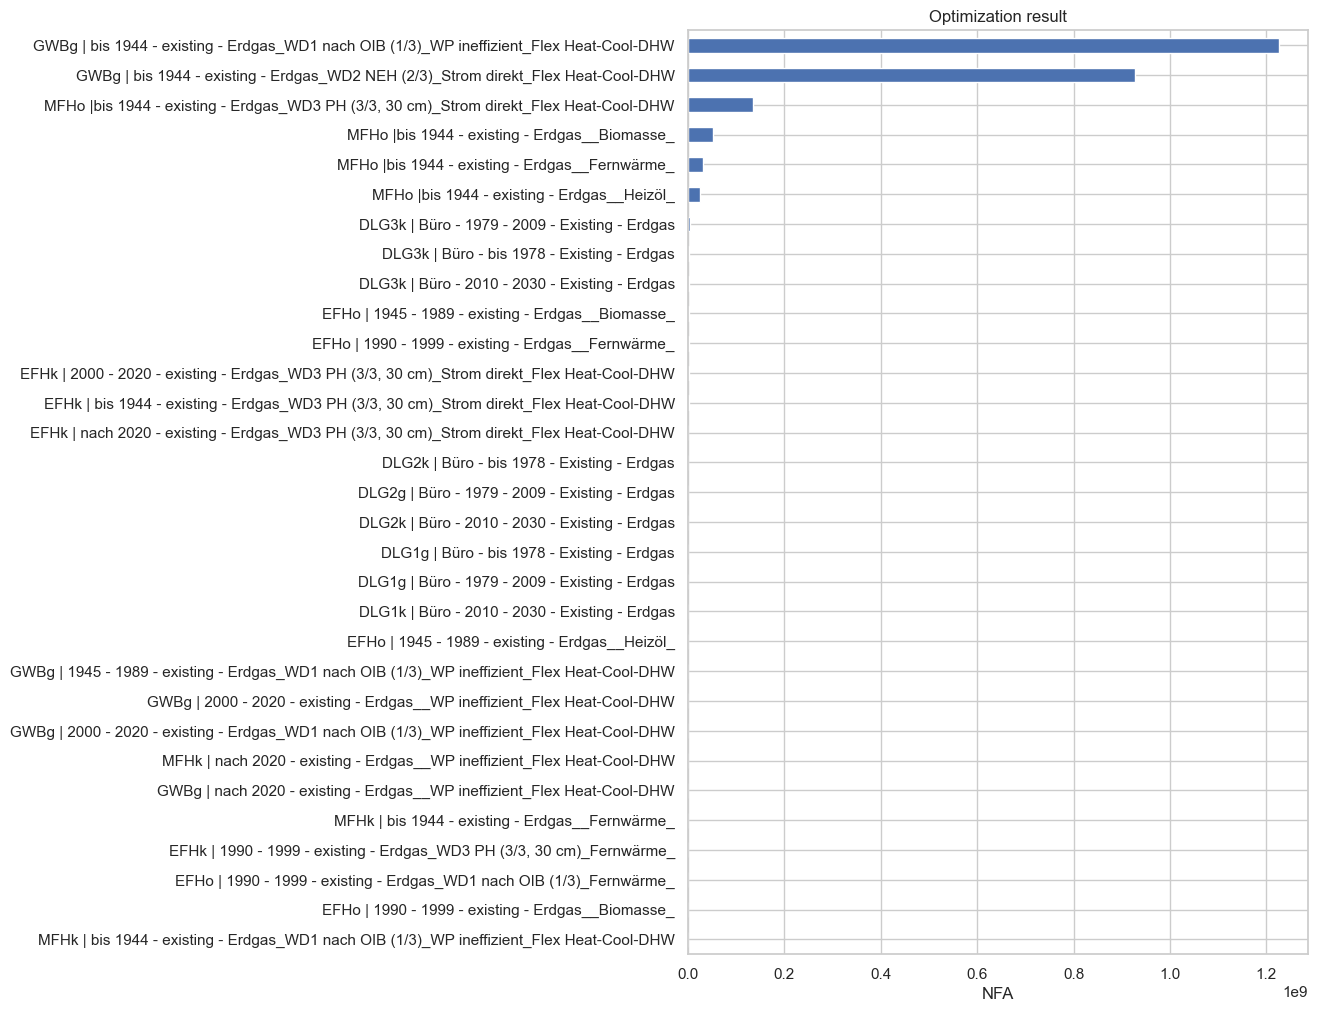

In [26]:

# If the archetype table has a Name column, the plot labels are easier to read.
if "Name" in result.columns:
    bs.plot_result(label_col="Name", value_col="NFA", sort=True, figsize=(8, 12))
else:
    bs.plot_result(value_col="NFA", sort=True, figsize=(8, 12))



## 12. Inspect slack variables

Slack variables show how much each soft constraint was violated.

For every constraint, the model creates:

- `s_<constraint>_pos`
- `s_<constraint>_neg`

Large slacks indicate one of these issues:

- the target is inconsistent with other targets
- a filter value does not match the archetype table
- a target column is wrong or missing
- the optimization did not have enough time


In [27]:

slack_rows = []

for variable in bs.model.variables():
    if variable.name.startswith("s_"):
        value = variable.varValue
        if value is None:
            value = 0
        slack_rows.append({"variable": variable.name, "slack": value})

slack_df = pd.DataFrame(slack_rows)

if len(slack_df) > 0:
    slack_df["abs_slack"] = slack_df["slack"].abs()
    slack_df = slack_df.sort_values("abs_slack", ascending=False)

display(slack_df.head(20))


,variable,slack,abs_slack
8,s_EE_4_neg,1.125155e+10,1.125155e+10
10,s_EE_5_neg,7.109518e+09,7.109518e+09
313,s_Stat_AT_NGF_40_pos,3.818311e+07,3.818311e+07
257,s_Stat_AT_NGF_36_pos,3.547537e+07,3.547537e+07
323,s_Stat_AT_NGF_41_pos,3.531729e+07,3.531729e+07
327,s_Stat_AT_NGF_43_pos,2.767847e+07,2.767847e+07
289,s_Stat_AT_NGF_39_pos,2.316466e+07,2.316466e+07
403,s_Stat_AT_NGF_49_pos,2.189166e+07,2.189166e+07
415,s_Stat_AT_NGF_50_pos,2.157123e+07,2.157123e+07
329,s_Stat_AT_NGF_44_pos,2.140536e+07,2.140536e+07


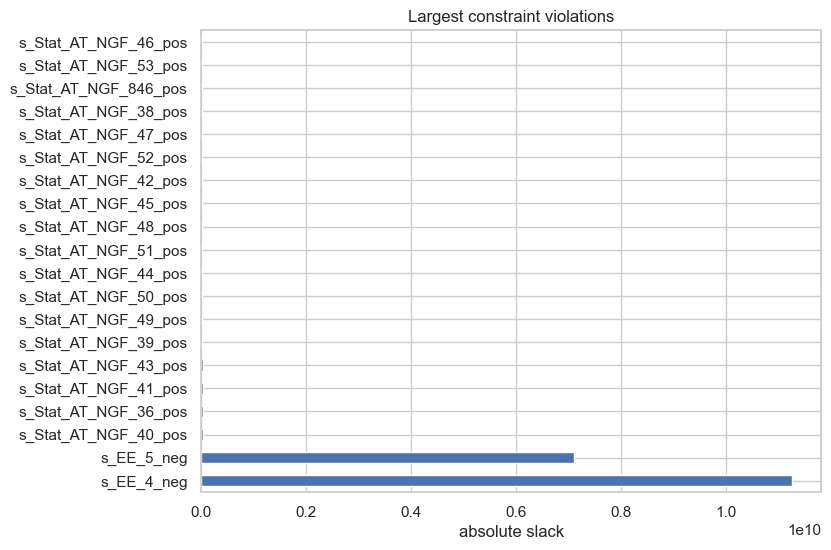

In [28]:

# Plot the largest non-zero slacks.
slack_plot_df = slack_df[slack_df["abs_slack"] > 0].head(20)

if len(slack_plot_df) > 0:
    slack_plot_df = slack_plot_df.set_index("variable")
    slack_plot_df["abs_slack"].plot(kind="barh", figsize=(8, 6))
    plt.xlabel("absolute slack")
    plt.ylabel("")
    plt.title("Largest constraint violations")
else:
    print("No non-zero slacks found.")


### Oh no!
The slack variables are very high for all constraints, which means something went very wrong. The reason is that the initial NGF constraints included all regions (Wien, etc.) as well as Targets, but we did not filter for them, because the region is no archetype category. We must exclude all constraints where column ``"Region – Gebietsstand 2023 (Ebene +2)"`` is not  ``"Zusammen"`` constraints from NGF first.



In [29]:
# Optional: filter the constraint table to one region or aggregate row.
REGION_COL = "Region – Gebietsstand 2023 (Ebene +2)"
REGION_VALUE = "Zusammen"

if REGION_COL in ngf_constraints_df.columns:
    ngf_constraints_df = ngf_constraints_df[ngf_constraints_df[REGION_COL].eq(REGION_VALUE)].copy()

print("Constraints after optional region filter:", ngf_constraints_df.shape)
display(ngf_constraints_df)

Constraints after optional region filter: (90, 13)


,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,target_column,target_value,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,983229,NaN,NaN,Zusammen,Andere Gebäude,bis 1978,179440026.0
1,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,391933,NaN,NaN,Zusammen,Andere Gebäude,1979 - 2009,120106016.0
2,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,594234,NaN,NaN,Zusammen,Andere Gebäude,2010 - 2030,29680973.0
3,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,629490,NaN,NaN,Zusammen,Wohngebäude,bis 1944,99641747.0
4,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,bis 1978,NaN,634503,NaN,NaN,Zusammen,Wohngebäude,1945 - 1989,227405833.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,2021,Zusammen,Wohngebäude,1 000 Quadratmeter und mehr,1945 - 1989,NaN,16136574,NaN,NaN,NaN,NaN,NaN,NaN
86,2021,Zusammen,Wohngebäude,1 000 Quadratmeter und mehr,1945 - 1989,NaN,9391856,NaN,NaN,NaN,NaN,NaN,NaN
87,2021,Zusammen,Wohngebäude,1 000 Quadratmeter und mehr,1990 - 1999,NaN,7838404,NaN,NaN,NaN,NaN,NaN,NaN
88,2021,Zusammen,Wohngebäude,1 000 Quadratmeter und mehr,2000 - 2020,NaN,12858774,NaN,NaN,NaN,NaN,NaN,NaN


## Redo NGF constraints

The `BuildingSector` object stores constraint definitions in `bs.constraints`.

When the constraints change (e.g Excel sheet changes or errors), do **not** try to edit the already-built PuLP model directly. Instead:

1. remove the old NGF constraints from `bs.constraints`
2. (if the underlying excel changed) reload the sheet from Excel
3. add the constraints again
4. call `bs.solve()` again

The PuLP model itself is rebuilt fresh inside `bs.solve()`, so this is the safest workflow.

In [30]:
bs.list_constraints()

,name,type,filter,column,target,weight
0,Stat_AT_NGF_0,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,9.832290e+05,1000000
1,Stat_AT_NGF_1,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,3.919330e+05,1000000
2,Stat_AT_NGF_2,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,5.942340e+05,1000000
3,Stat_AT_NGF_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,6.294900e+05,1000000
4,Stat_AT_NGF_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,6.345030e+05,1000000
...,...,...,...,...,...,...
903,EE_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10,1
904,EE_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09,1
905,EE_5,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09,1
906,EE_6,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Warmwasser_Endenergiebedarf_kWh/m²NGFa,1.073889e+10,1


In [31]:

bs.remove_constraints("Stat_AT_NGF")
bs.list_constraints()

,name,type,filter,column,target,weight
0,EE_0,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Gas_Quartier_kWh/m²NGFa,1.703739e+10,1
1,EE_1,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Biomasse_Quartier_kWh/m²NGFa,1.972013e+10,1
2,EE_2,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Fernwärme_Quartier_kWh/m²NGFa,9.715264e+09,1
3,EE_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10,1
4,EE_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09,1
5,EE_5,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09,1
6,EE_6,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Warmwasser_Endenergiebedarf_kWh/m²NGFa,1.073889e+10,1
7,EE_7,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Heizen_Endenergiebedarf_kWh/m²NGFa,5.198375e+10,1


In [32]:
bs.add_constraints_from_df(
    constraints_df=ngf_constraints_df,
    filter_cols=ngf_filter_cols,
    target="target_value",
    target_column_col="target_column",
    weight=1_000_000,
    name_prefix="Stat_AT_NGF",
)


In [33]:

bs.list_constraints()

,name,type,filter,column,target,weight
0,EE_0,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Gas_Quartier_kWh/m²NGFa,1.703739e+10,1
1,EE_1,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Biomasse_Quartier_kWh/m²NGFa,1.972013e+10,1
2,EE_2,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Fernwärme_Quartier_kWh/m²NGFa,9.715264e+09,1
3,EE_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10,1
4,EE_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09,1
...,...,...,...,...,...,...
93,Stat_AT_NGF_85,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,1.613657e+07,1000000
94,Stat_AT_NGF_86,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,9.391856e+06,1000000
95,Stat_AT_NGF_87,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,7.838404e+06,1000000
96,Stat_AT_NGF_88,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,1.285877e+07,1000000


Skipping Stat_AT_NGF_9: no matching archetypes
Skipping Stat_AT_NGF_10: no matching archetypes
Skipping Stat_AT_NGF_11: no matching archetypes
Skipping Stat_AT_NGF_12: no matching archetypes
Skipping Stat_AT_NGF_13: no matching archetypes
Skipping Stat_AT_NGF_14: no matching archetypes
Skipping Stat_AT_NGF_15: no matching archetypes
Skipping Stat_AT_NGF_16: no matching archetypes
Skipping Stat_AT_NGF_17: no matching archetypes
Skipping Stat_AT_NGF_27: no matching archetypes
Skipping Stat_AT_NGF_28: no matching archetypes
Skipping Stat_AT_NGF_29: no matching archetypes
Skipping Stat_AT_NGF_30: no matching archetypes
Skipping Stat_AT_NGF_31: no matching archetypes
Skipping Stat_AT_NGF_32: no matching archetypes
Skipping Stat_AT_NGF_33: no matching archetypes
Skipping Stat_AT_NGF_34: no matching archetypes
Skipping Stat_AT_NGF_35: no matching archetypes
Skipping Stat_AT_NGF_54: no matching archetypes
Skipping Stat_AT_NGF_55: no matching archetypes
Skipping Stat_AT_NGF_56: no matching arch

<Axes: title={'center': 'Optimization result'}, xlabel='NFA'>

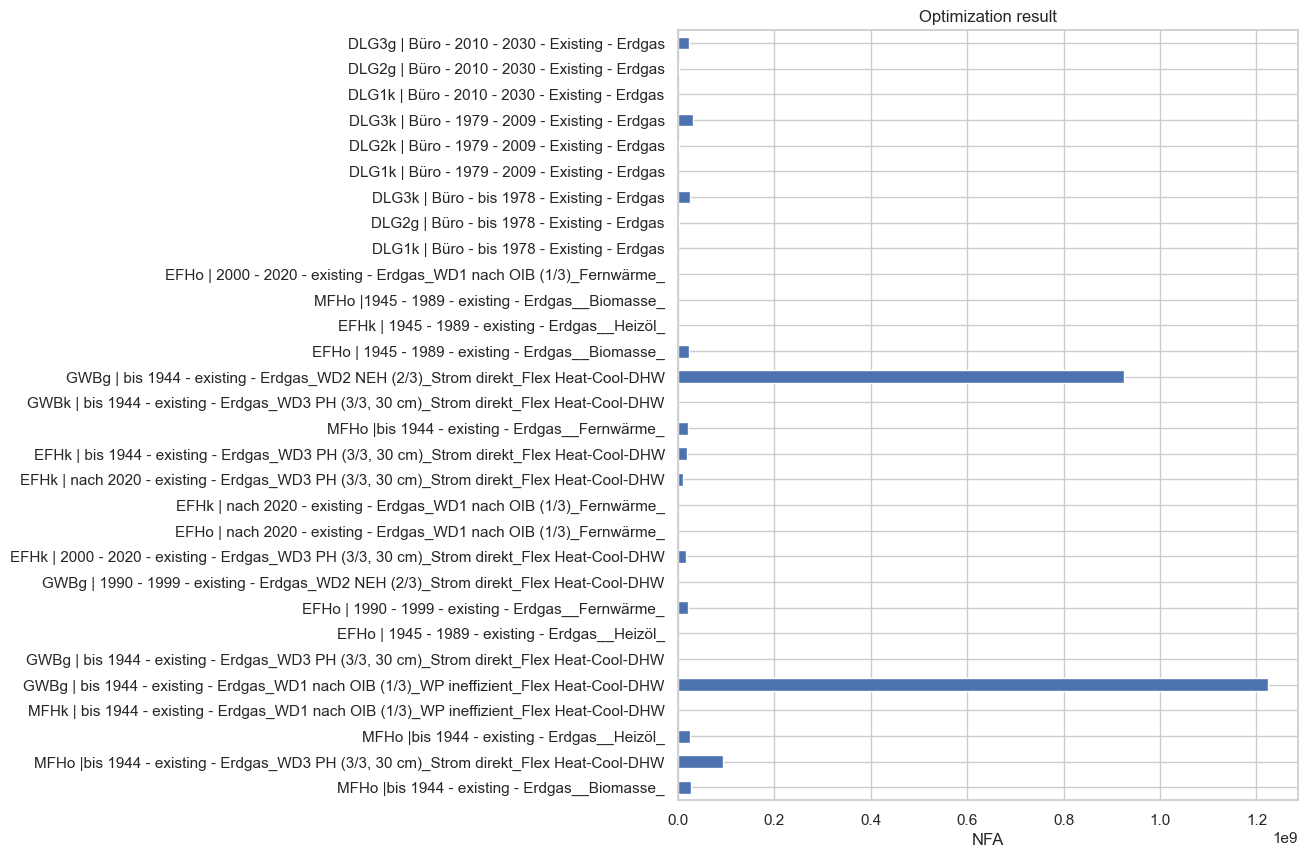

In [34]:
bs.solve()
result = bs.result_df(value_col="NFA")
bs.plot_result()

<Axes: ylabel='name'>

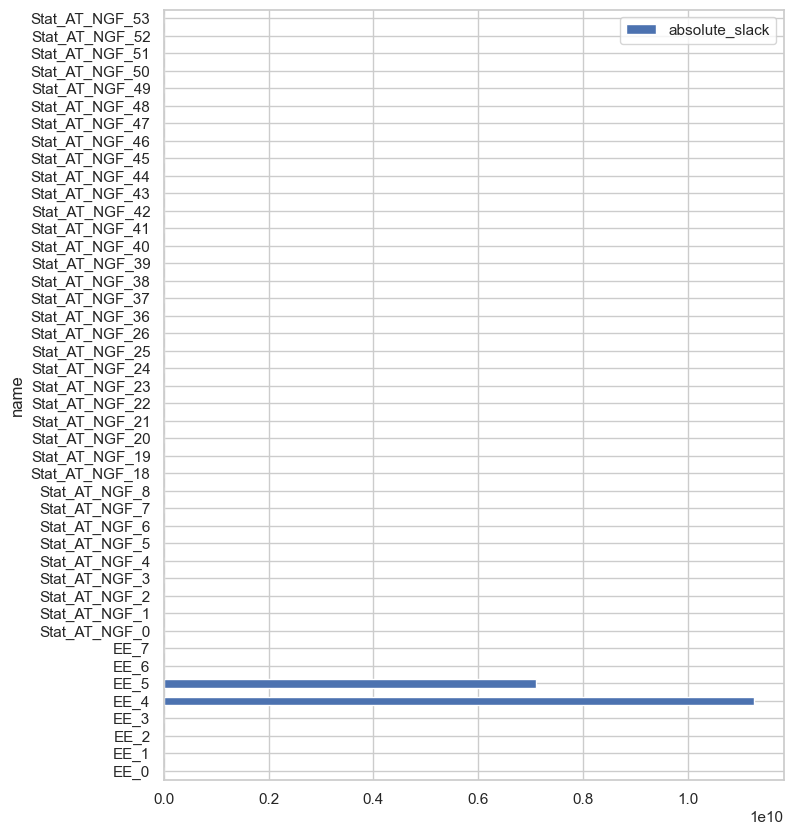

In [35]:

slacks = bs.slack_df()
slacks.head()
slacks.plot(
    x="name",
    y="absolute_slack",
    kind="barh",
    figsize=(8, 10),
)


## 13. Evaluate all constraints explicitly

The next helper function is useful because we will evaluate constraints several times:

- after the first solve
- after changing Excel and redoing constraints
- after comparing variants

The function calculates the left-hand side and right-hand side of every stored constraint using the solved result dataframe.


In [36]:

# A function groups reusable code:
# https://docs.python.org/3/tutorial/controlflow.html#defining-functions
def evaluate_constraints(bs, result):
    rows = []

    for c in bs.constraints:
        selected_ids = bs._filter_indices(c.filter)

        lhs = 0
        for i in selected_ids:
            if c.column is None:
                multiplier = 1
            else:
                multiplier = bs.archetypes.at[i, c.column]
            lhs = lhs + result.at[i, "NFA"] * multiplier

        if c.type == "absolute":
            rhs = c.target
        elif c.type == "share":
            reference_ids = bs._filter_indices(c.reference_filter)
            reference_lhs = 0
            for i in reference_ids:
                if c.column is None:
                    multiplier = 1
                else:
                    multiplier = bs.archetypes.at[i, c.column]
                reference_lhs = reference_lhs + result.at[i, "NFA"] * multiplier
            rhs = c.target * reference_lhs
        else:
            rhs = np.nan

        rows.append({
            "name": c.name,
            "type": c.type,
            "column": c.column,
            "target": c.target,
            "lhs": lhs,
            "rhs": rhs,
            "deviation": lhs - rhs,
            "relative_deviation": (lhs - rhs) / rhs if rhs != 0 else np.nan,
            "n_selected_archetypes": len(selected_ids),
            "filter": c.filter,
        })

    return pd.DataFrame(rows)


In [37]:

constraint_eval_df = evaluate_constraints(bs, result)

# Show the largest relative deviations.
display(
    constraint_eval_df
    .assign(abs_relative_deviation=lambda df: df["relative_deviation"].abs())
    .sort_values("abs_relative_deviation", ascending=False)
    .head(20)
)


,name,type,column,target,lhs,rhs,deviation,relative_deviation,n_selected_archetypes,filter,abs_relative_deviation
5,EE_5,absolute,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09,9.308996e+09,2.204916e+09,7.104080e+09,3.221928,1440,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,3.221928
4,EE_4,absolute,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09,1.482525e+10,3.566548e+09,1.125870e+10,3.156750,480,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,3.156750
45,Stat_AT_NGF_37,absolute,None,1.063716e+07,2.566113e+07,1.063716e+07,1.502397e+07,1.412404,2,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,1.412404
25,Stat_AT_NGF_17,absolute,None,5.014650e+05,0.000000e+00,5.014650e+05,-5.014650e+05,-1.000000,0,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,1.000000
17,Stat_AT_NGF_9,absolute,None,1.223343e+06,0.000000e+00,1.223343e+06,-1.223343e+06,-1.000000,0,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,1.000000
24,Stat_AT_NGF_16,absolute,None,6.937480e+05,0.000000e+00,6.937480e+05,-6.937480e+05,-1.000000,0,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,1.000000
21,Stat_AT_NGF_13,absolute,None,8.442200e+05,0.000000e+00,8.442200e+05,-8.442200e+05,-1.000000,0,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,1.000000
20,Stat_AT_NGF_12,absolute,None,8.177020e+05,0.000000e+00,8.177020e+05,-8.177020e+05,-1.000000,0,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,1.000000
19,Stat_AT_NGF_11,absolute,None,7.424920e+05,0.000000e+00,7.424920e+05,-7.424920e+05,-1.000000,0,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,1.000000
22,Stat_AT_NGF_14,absolute,None,7.926410e+05,0.000000e+00,7.926410e+05,-7.926410e+05,-1.000000,0,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,1.000000


In [38]:

# Separate NGF and EE deviations by name prefix.
ngf_eval_df = constraint_eval_df[constraint_eval_df["name"].str.startswith("Stat_AT_NGF")]
ee_eval_df = constraint_eval_df[constraint_eval_df["name"].str.startswith("Stat_AT_EE")]

print("NGF constraints:", len(ngf_eval_df))
print("EE constraints:", len(ee_eval_df))

display(ee_eval_df[["name", "column", "lhs", "rhs", "deviation", "relative_deviation", "filter"]])


NGF constraints: 90
EE constraints: 0


,name,column,lhs,rhs,deviation,relative_deviation,filter



## 14. Calculate total indicators

Because `NFA` is the decision variable, total quantities are calculated as:


$total_X = \sum_i NFA_i \cdot x_i$


where `x_i` is an archetype column such as `kWh/m²NGFa` or `kgCO₂/m²NGFa`.


In [39]:

# Use the target columns from the EE sheet as a first set of energy indicators.
energy_indicator_cols = []

for col in ee_constraints_df[TARGET_COLUMN_COL].dropna().drop_duplicates():
    if col in result.columns:
        energy_indicator_cols.append(col)

print("Energy indicator columns found in archetype_df:")
for col in energy_indicator_cols:
    print("-", col)


Energy indicator columns found in archetype_df:
- Gas_Quartier_kWh/m²NGFa
- Biomasse_Quartier_kWh/m²NGFa
- Fernwärme_Quartier_kWh/m²NGFa
- Sonstige_Quartier_kWh/m²NGFa
- Netzstrom_Heizen_kWh/m²NGFa
- Warmwasser_Endenergiebedarf_kWh/m²NGFa
- Heizen_Endenergiebedarf_kWh/m²NGFa


In [40]:

indicator_rows = []

for col in energy_indicator_cols:
    total_value = (result["NFA"] * result[col]).sum()
    specific_value = total_value / result["NFA"].sum()
    indicator_rows.append({
        "indicator": col,
        "total": total_value,
        "weighted_mean_per_m2_NFA": specific_value,
    })

energy_summary_df = pd.DataFrame(indicator_rows)
display(energy_summary_df)


,indicator,total,weighted_mean_per_m2_NFA
0,Gas_Quartier_kWh/m²NGFa,1.737327e+10,6.960326
1,Biomasse_Quartier_kWh/m²NGFa,1.972013e+10,7.900556
2,Fernwärme_Quartier_kWh/m²NGFa,9.715264e+09,3.892266
3,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10,4.348880
4,Netzstrom_Heizen_kWh/m²NGFa,2.738334e+10,10.970701
5,Warmwasser_Endenergiebedarf_kWh/m²NGFa,1.075401e+10,4.308423
6,Heizen_Endenergiebedarf_kWh/m²NGFa,5.454768e+10,21.853661


In [41]:

# Optional: search for CO2 or GHG columns in the archetype table.
co2_cols = []

for col in result.columns:
    lower_name = col.lower()
    if "co2" in lower_name or "ghg" in lower_name or "emission" in lower_name:
        co2_cols.append(col)

print("Possible CO2/GHG columns:")
for col in co2_cols:
    print("-", col)


Possible CO2/GHG columns:
- Bauteil Außenwand fossil__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Außenwand biogen__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Außenwand__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Fenster fossil__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Fenster biogen__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Fenster __GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Dach fossil__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Dach biogen__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Dach__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Decke gegen Erdreich / Keller fossil__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Decke gegen Erdreich / Keller biogen__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Decke gegen Erdreich / Keller__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Zwischengeschoßdecken fossil__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Zwischengeschoßdecken biogen__GWP 100A (kgCO2equiv/m²BGF)
- Bauteil Zwischengeschoßdecken__GWP 100A (kgCO2equiv/m²BGF)
- Baulich Allgemein fossil__GWP 100A (kgCO2equiv/m²BGF)
- Baulich Allgemein biogen__GWP 100A 

In [42]:

co2_summary_rows = []

for col in co2_cols:
    # Only calculate totals for numeric columns.
    if pd.api.types.is_numeric_dtype(result[col]):
        total_value = (result["NFA"] * result[col]).sum()
        specific_value = total_value / result["NFA"].sum()
        co2_summary_rows.append({
            "indicator": col,
            "total": total_value,
            "weighted_mean_per_m2_NFA": specific_value,
        })

co2_summary_df = pd.DataFrame(co2_summary_rows)
display(co2_summary_df)


,indicator,total,weighted_mean_per_m2_NFA
0,Bauteil Außenwand fossil__GWP 100A (kgCO2equiv...,0.0,0.0
1,Bauteil Außenwand biogen__GWP 100A (kgCO2equiv...,0.0,0.0
2,Bauteil Außenwand__GWP 100A (kgCO2equiv/m²BGF),0.0,0.0
3,Bauteil Fenster fossil__GWP 100A (kgCO2equiv/m...,0.0,0.0
4,Bauteil Fenster biogen__GWP 100A (kgCO2equiv/m...,0.0,0.0
...,...,...,...
95,LCA OE MIV fossil_2025-2050_GWP 100S (kgCO2equ...,0.0,0.0
96,Mobilität_2025-2050_GWP 100S (kgCO2equiv/m²BGF),0.0,0.0
97,THG-Emissionen 2025-2075_2025-2050_GWP 100S (k...,0.0,0.0
98,OE THG-Emissionen 2025-2075_2025-2050_GWP 100S...,0.0,0.0



## 15. Aggregate NFA by categories

This is often the most important plausibility check:

- How much NFA is assigned to each construction period?
- Which size classes dominate?
- Which heating or energy supply systems appear?


In [43]:

USE_COL = "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)"
SIZE_COL = "Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)"
AGE_COL = "Bauperiode (Ebene +2)"

if "Energy Supply" in result.columns:
    ENERGY_COL = "Energy Supply"
elif "EnergySupply" in result.columns:
    ENERGY_COL = "EnergySupply"
else:
    ENERGY_COL = None

if "Building Quality" in result.columns:
    QUALITY_COL = "Building Quality"
else:
    QUALITY_COL = None

print("ENERGY_COL:", ENERGY_COL)
print("QUALITY_COL:", QUALITY_COL)


ENERGY_COL: Energy Supply
QUALITY_COL: Building Quality


Text(0.5, 1.0, 'Optimized NFA by construction period')

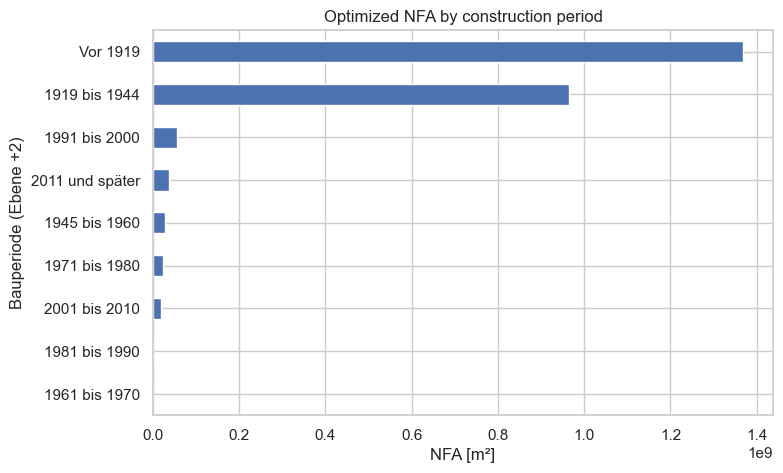

In [44]:

# groupby groups rows by category and then sums NFA:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
nfa_by_age = result.groupby(AGE_COL, dropna=False)["NFA"].sum().sort_values()

nfa_by_age.plot(kind="barh", figsize=(8, 5))
plt.xlabel("NFA [m²]")
plt.ylabel(AGE_COL)
plt.title("Optimized NFA by construction period")


Text(0.5, 1.0, 'Optimized NFA by size class')

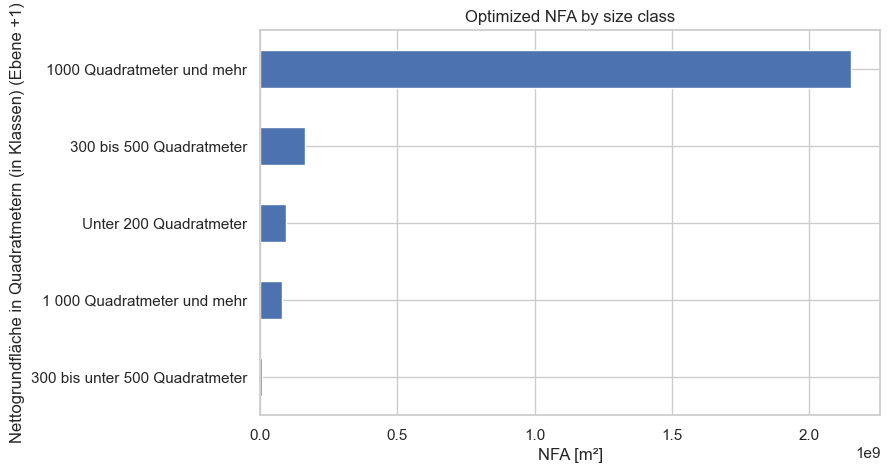

In [45]:

nfa_by_size = result.groupby(SIZE_COL, dropna=False)["NFA"].sum().sort_values()

nfa_by_size.plot(kind="barh", figsize=(8, 5))
plt.xlabel("NFA [m²]")
plt.ylabel(SIZE_COL)
plt.title("Optimized NFA by size class")


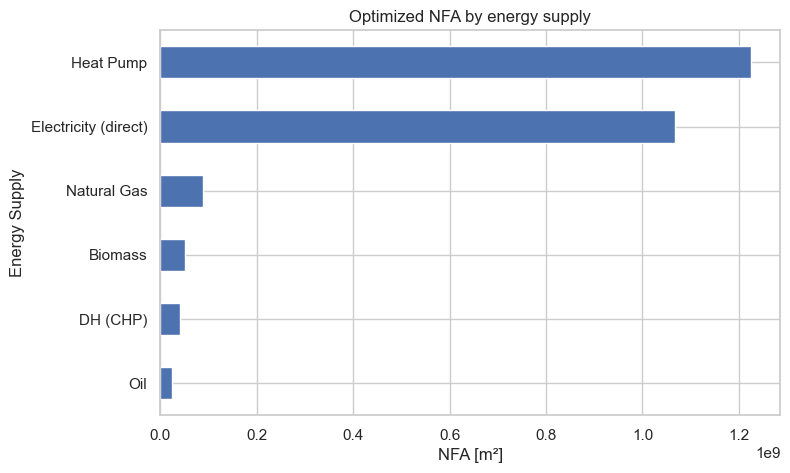

In [46]:

if ENERGY_COL is not None:
    nfa_by_energy = result.groupby(ENERGY_COL, dropna=False)["NFA"].sum().sort_values()
    nfa_by_energy.plot(kind="barh", figsize=(8, 5))
    plt.xlabel("NFA [m²]")
    plt.ylabel(ENERGY_COL)
    plt.title("Optimized NFA by energy supply")
else:
    print("No energy supply column found.")



## 16. Seaborn categorized plots

Seaborn is useful for comparing categories with facets and colors.

Typical plot ideas:

- NFA by construction period, colored by energy supply
- NFA by size class, faceted by building use
- specific energy demand by building quality and energy supply


In [47]:

# Use only selected archetypes for plots. This keeps figures readable.
plot_data = result[result["NFA"] > 0].copy()

print("Rows used for plots:", len(plot_data))


Rows used for plots: 30


Text(0.5, 1.0, 'NFA by construction period')

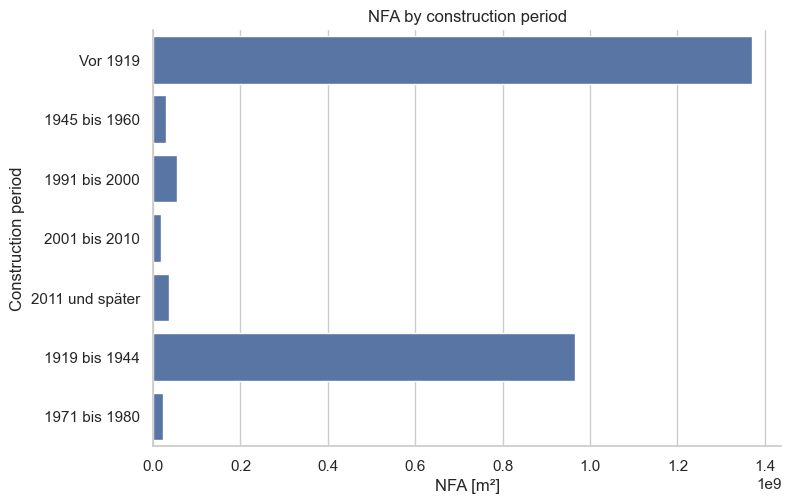

In [48]:

# Bar plot: NFA by construction period.
# estimator="sum" tells seaborn to sum NFA values within each category.
sns.catplot(
    data=plot_data,
    y=AGE_COL,
    x="NFA",
    kind="bar",
    estimator=sum,
    errorbar=None,
    height=5,
    aspect=1.6,
)
plt.xlabel("NFA [m²]")
plt.ylabel("Construction period")
plt.title("NFA by construction period")


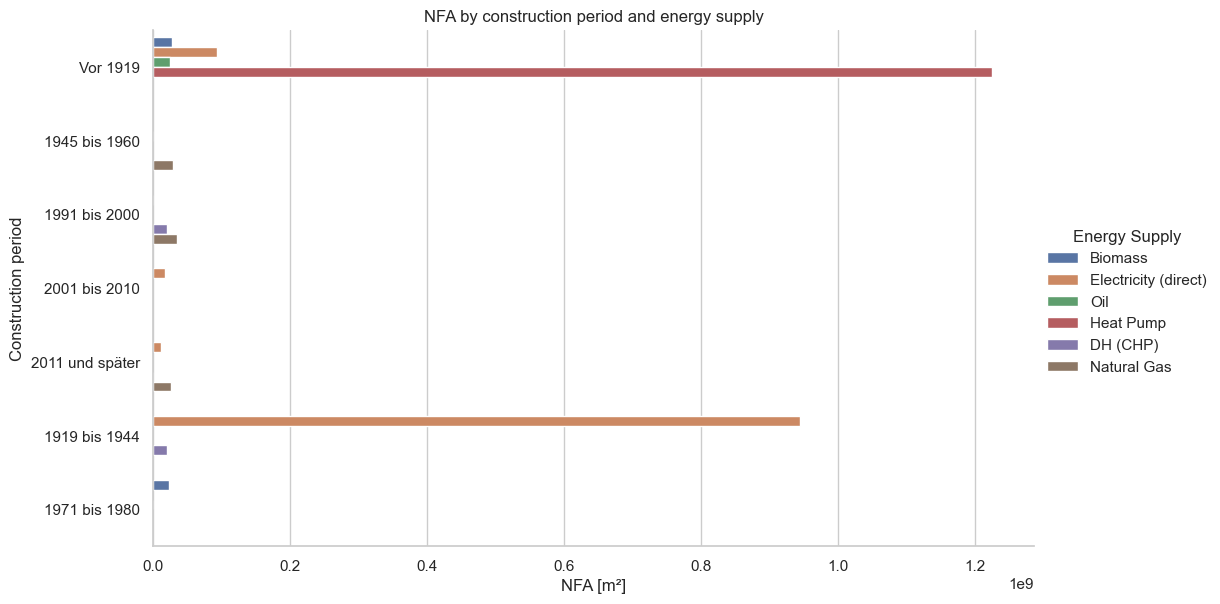

In [49]:

# Categorized plot: construction period by energy supply.
if ENERGY_COL is not None:
    sns.catplot(
        data=plot_data,
        y=AGE_COL,
        x="NFA",
        hue=ENERGY_COL,
        kind="bar",
        estimator=sum,
        errorbar=None,
        height=6,
        aspect=1.8,
    )
    plt.xlabel("NFA [m²]")
    plt.ylabel("Construction period")
    plt.title("NFA by construction period and energy supply")
else:
    print("No energy supply column found.")


Text(647.3045014880952, 0.5, 'Construction period')

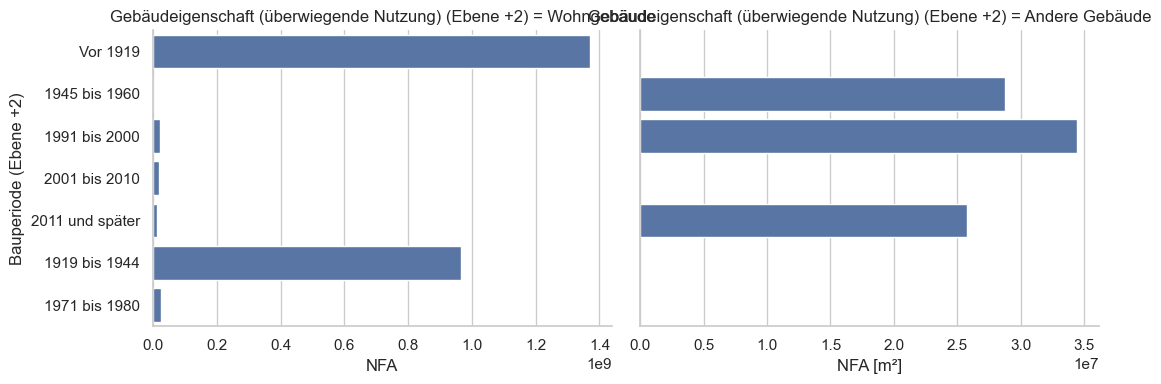

In [50]:

# Faceted plot: one panel per building use.
# col_wrap limits the number of panels per row.
sns.catplot(
    data=plot_data,
    y=AGE_COL,
    x="NFA",
    col=USE_COL,
    kind="bar",
    estimator=sum,
    errorbar=None,
    col_wrap=2,
    height=4,
    aspect=1.4,
    sharex=False,
)
plt.xlabel("NFA [m²]")
plt.ylabel("Construction period")


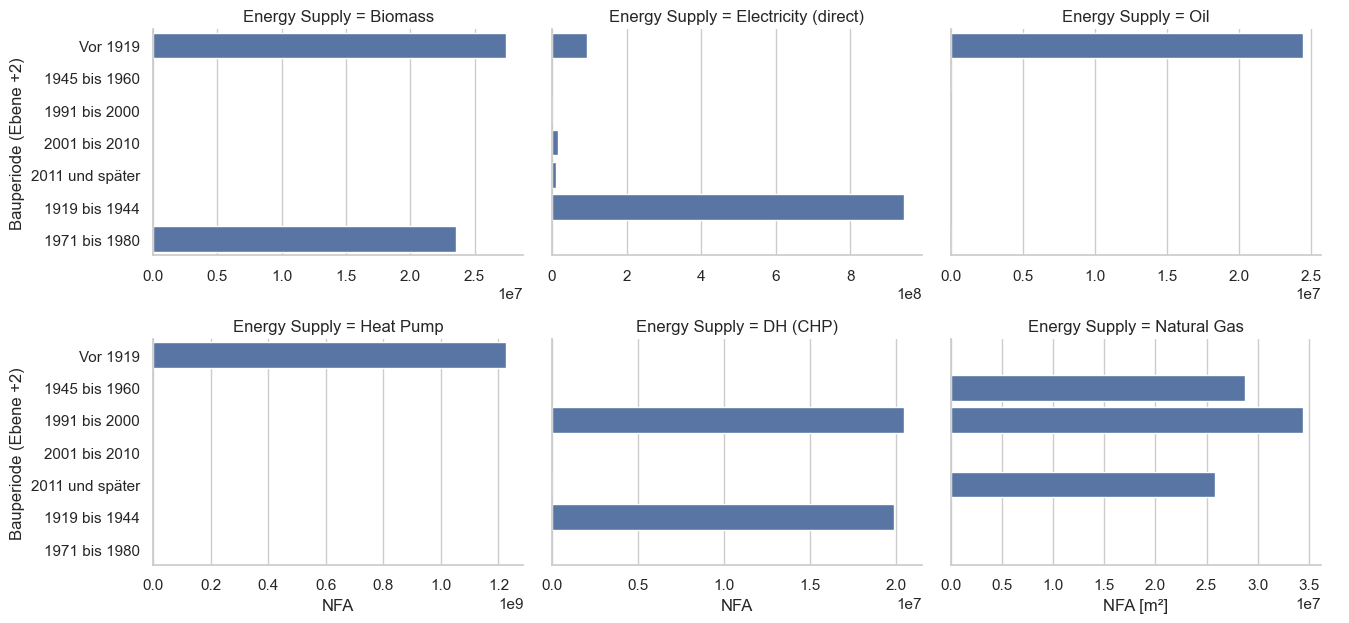

In [51]:

# Faceted plot by energy supply, if available.
# To avoid too many facets, use the largest energy supply categories only.
if ENERGY_COL is not None:
    top_energy_categories = (
        plot_data.groupby(ENERGY_COL)["NFA"]
        .sum()
        .sort_values(ascending=False)
        .head(6)
        .index
    )

    plot_data_top_energy = plot_data[plot_data[ENERGY_COL].isin(top_energy_categories)]

    sns.catplot(
        data=plot_data_top_energy,
        y=AGE_COL,
        x="NFA",
        col=ENERGY_COL,
        kind="bar",
        estimator=sum,
        errorbar=None,
        col_wrap=3,
        height=3.2,
        aspect=1.4,
        sharex=False,
    )
    plt.xlabel("NFA [m²]")
    plt.ylabel("Construction period")
else:
    print("No energy supply column found.")


Using indicator: Gas_Quartier_kWh/m²NGFa


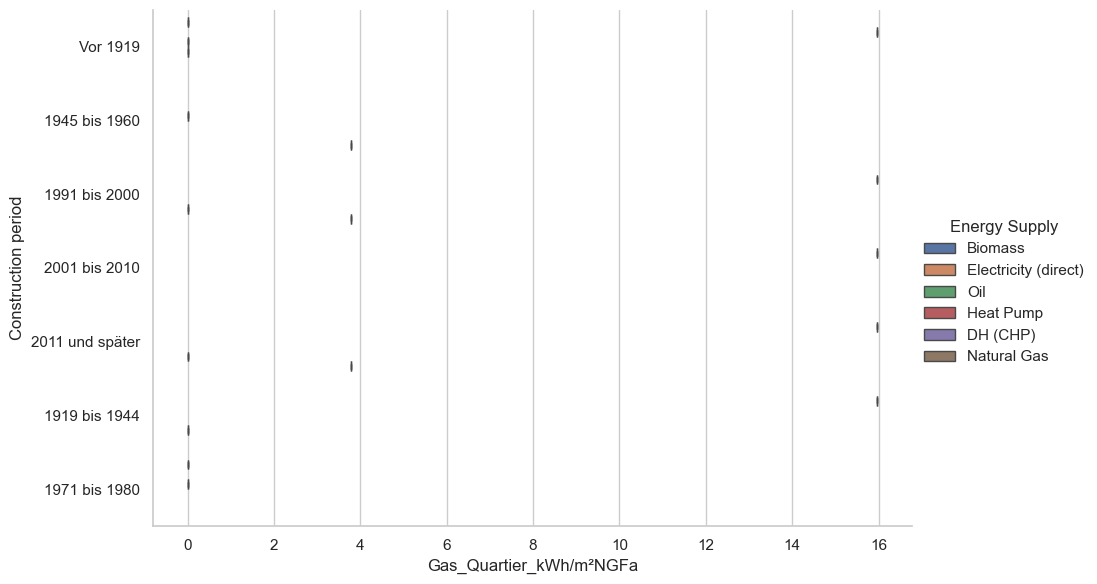

In [52]:

# Specific energy demand by category.
# Pick the first EE indicator that exists.
if len(energy_indicator_cols) > 0:
    ENERGY_INDICATOR = energy_indicator_cols[0]
    print("Using indicator:", ENERGY_INDICATOR)

    sns.catplot(
        data=plot_data,
        x=ENERGY_INDICATOR,
        y=AGE_COL,
        hue=ENERGY_COL if ENERGY_COL is not None else None,
        kind="box",
        height=6,
        aspect=1.6,
    )
    plt.xlabel(ENERGY_INDICATOR)
    plt.ylabel("Construction period")
else:
    print("No EE indicator columns found.")


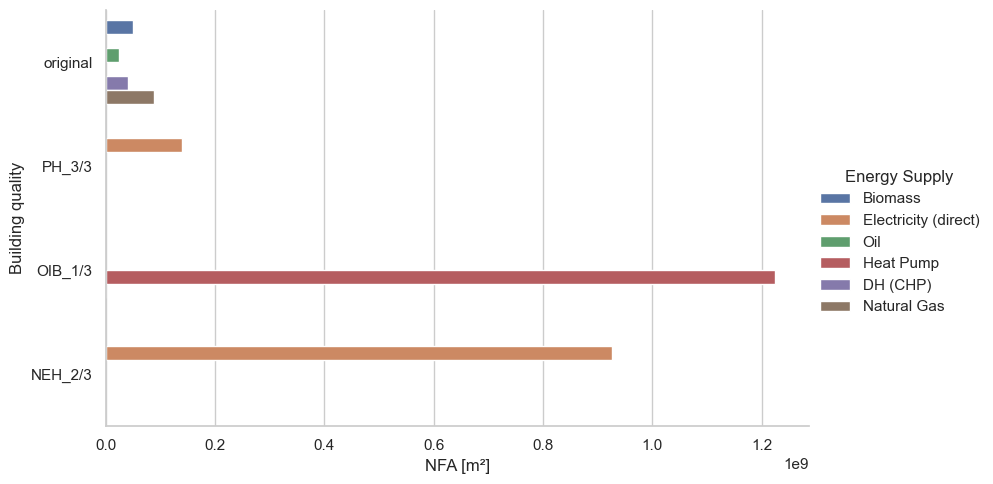

In [53]:

# If a building quality column exists, compare NFA distribution by quality.
if QUALITY_COL is not None:
    sns.catplot(
        data=plot_data,
        y=QUALITY_COL,
        x="NFA",
        hue=ENERGY_COL if ENERGY_COL is not None else None,
        kind="bar",
        estimator=sum,
        errorbar=None,
        height=5,
        aspect=1.7,
    )
    plt.xlabel("NFA [m²]")
    plt.ylabel("Building quality")
else:
    print("No Building Quality column found.")



## 17. Pivot tables for compact summaries

Pivot tables are useful for comparing two categories at once.


In [54]:

# A pivot table summarizes values across two category dimensions:
# https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html
nfa_pivot_age_energy = pd.pivot_table(
    result,
    values="NFA",
    index=AGE_COL,
    columns=ENERGY_COL if ENERGY_COL is not None else USE_COL,
    aggfunc="sum",
    fill_value=0,
)

display(nfa_pivot_age_energy)


Energy Supply,Biomass,DH (CHP),Electricity (direct),Heat Pump,Natural Gas,Oil
Bauperiode (Ebene +2),,,,,,
1919 bis 1944,0.0,19847180.0,944790350.0,0.000000e+00,0.0,0.0
1945 bis 1960,0.0,0.0,0.0,0.000000e+00,28750623.0,16.0
1961 bis 1970,0.0,0.0,0.0,0.000000e+00,0.0,0.0
1971 bis 1980,23518939.0,0.0,0.0,0.000000e+00,0.0,1.0
1981 bis 1990,0.0,0.0,0.0,0.000000e+00,0.0,0.0
1991 bis 2000,0.0,20471461.0,1.0,0.000000e+00,34459582.0,0.0
2001 bis 2010,0.0,0.0,17642538.0,0.000000e+00,0.0,0.0
2011 und später,0.0,6.0,11250882.0,0.000000e+00,25792902.0,0.0
Vor 1919,27409988.0,0.0,92778731.0,1.224838e+09,0.0,24491566.0


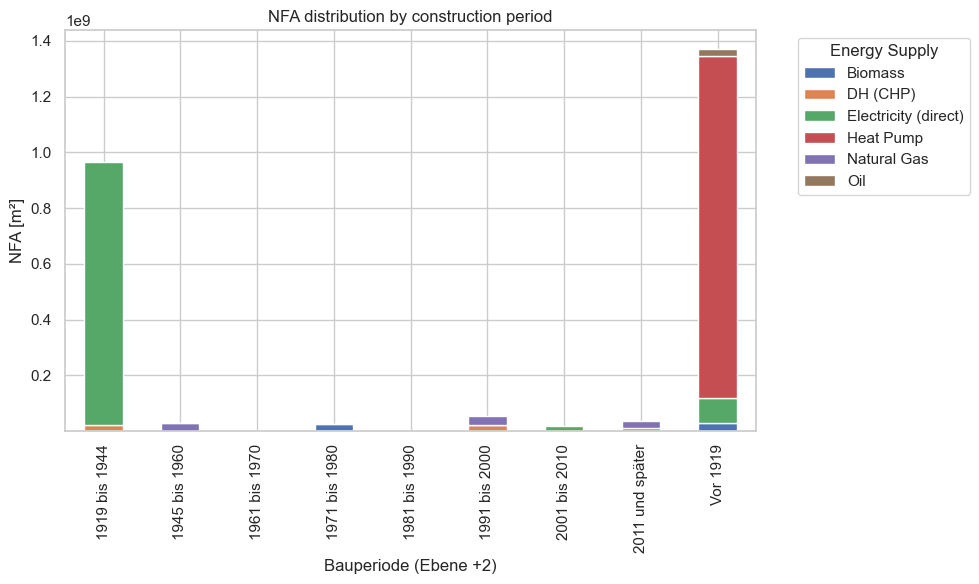

In [55]:

# Plot the pivot table as a stacked bar chart.
nfa_pivot_age_energy.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.ylabel("NFA [m²]")
plt.title("NFA distribution by construction period")
plt.legend(title=ENERGY_COL if ENERGY_COL is not None else USE_COL, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()



## 18. Energy totals by categories

The same weighted-sum logic can be used for grouped results.

Example:

\[
total\ energy\ in\ group = \sum_i NFA_i \cdot energy_i
\]


In [56]:

if len(energy_indicator_cols) > 0:
    ENERGY_INDICATOR = energy_indicator_cols[-1]
    print("Using indicator:", ENERGY_INDICATOR)

    energy_by_age_rows = []

    for age_value in result[AGE_COL].dropna().unique():
        rows_for_age = result[result[AGE_COL] == age_value]
        total_energy = (rows_for_age["NFA"] * rows_for_age[ENERGY_INDICATOR]).sum()
        total_nfa = rows_for_age["NFA"].sum()
        specific_energy = total_energy / total_nfa if total_nfa > 0 else np.nan
        energy_by_age_rows.append({
            AGE_COL: age_value,
            "total_energy": total_energy,
            "NFA": total_nfa,
            "specific_energy": specific_energy,
        })

    energy_by_age_df = pd.DataFrame(energy_by_age_rows)
    display(energy_by_age_df)
else:
    print("No energy indicators found.")


Using indicator: Heizen_Endenergiebedarf_kWh/m²NGFa


,Bauperiode (Ebene +2),total_energy,NFA,specific_energy
0,Vor 1919,2.258059e+10,1.369518e+09,16.487977
1,1945 bis 1960,1.586034e+09,2.875064e+07,55.165183
2,1991 bis 2000,9.483349e+08,5.493104e+07,17.264097
3,2001 bis 2010,3.374975e+08,1.764254e+07,19.129762
4,2011 und später,3.140196e+08,3.704379e+07,8.476984
5,1919 bis 1944,2.861681e+10,9.646375e+08,29.665873
6,1961 bis 1970,0.000000e+00,0.000000e+00,NaN
7,1971 bis 1980,1.643858e+08,2.351894e+07,6.989506
8,1981 bis 1990,0.000000e+00,0.000000e+00,NaN


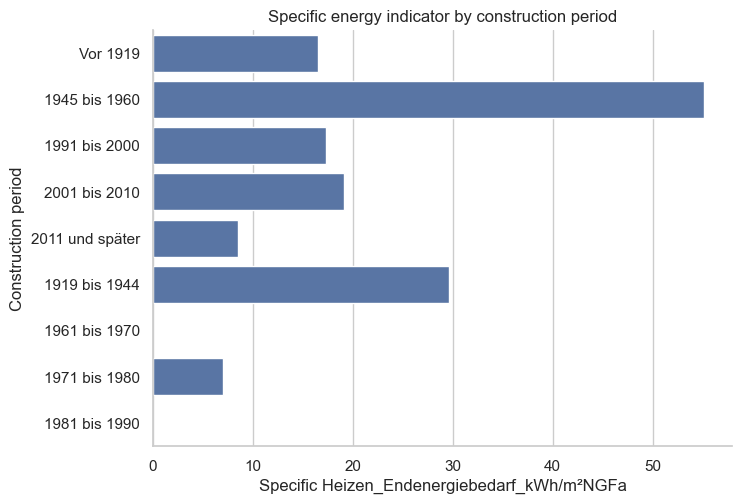

In [57]:

if len(energy_indicator_cols) > 0:
    sns.catplot(
        data=energy_by_age_df,
        y=AGE_COL,
        x="specific_energy",
        kind="bar",
        height=5,
        aspect=1.5,
    )
    plt.xlabel(f"Specific {ENERGY_INDICATOR}")
    plt.ylabel("Construction period")
    plt.title("Specific energy indicator by construction period")
else:
    print("No energy indicators found.")



## 19. Redo EE constraints after editing Excel

This is the recommended workflow if students change the `EE` sheet in Excel:

1. Save the Excel workbook.
2. Re-read only the `EE` sheet.
3. Remove old EE constraints from `bs.constraints`.
4. Add the updated EE constraints.
5. Solve again.

Do not try to edit constraints inside the already-built PuLP model. The PuLP model is rebuilt fresh in `bs.solve()`.


In [58]:

# Step 1 is manual: edit and save constraints_sector_model.xlsx in Excel.

# Step 2: re-read the EE sheet into the same variable name.
# Reusing ee_constraints_df here is intentional: it now represents the updated Excel sheet.
ee_constraints_df = pd.read_excel(CONSTRAINTS_PATH, sheet_name="EE")

# Step 3: remove old EE constraints by name prefix.
bs.remove_constraints("Stat_AT_EE")

# Step 4: add the new EE constraints.
bs.add_constraints_from_df(
    constraints_df=ee_constraints_df,
    filter_cols=ee_filter_cols,
    target=TARGET_VALUE_COL,
    target_column_col=TARGET_COLUMN_COL,
    weight=WEIGHT_EE,
    name_prefix="Stat_AT_EE",
)

print("Number of constraints after redoing EE:", len(bs.constraints))
display(bs.list_constraints().tail(12))


Number of constraints after redoing EE: 106


,name,type,filter,column,target,weight
94,Stat_AT_NGF_86,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,9.391856e+06,1000000
95,Stat_AT_NGF_87,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,7.838404e+06,1000000
96,Stat_AT_NGF_88,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,1.285877e+07,1000000
97,Stat_AT_NGF_89,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,2.917720e+07,1000000
98,Stat_AT_EE_0,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Gas_Quartier_kWh/m²NGFa,1.703739e+10,1
99,Stat_AT_EE_1,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Biomasse_Quartier_kWh/m²NGFa,1.972013e+10,1
100,Stat_AT_EE_2,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Fernwärme_Quartier_kWh/m²NGFa,9.715264e+09,1
101,Stat_AT_EE_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10,1
102,Stat_AT_EE_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09,1
103,Stat_AT_EE_5,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09,1


In [59]:

# Step 5: solve again and refresh result dataframes.
nfa_result = bs.solve(timeLimit=10)
result = bs.result_df(value_col="NFA")
positive_result = result[result["NFA"] > 0].copy()
constraint_eval_df = evaluate_constraints(bs, result)

display(constraint_eval_df[constraint_eval_df["name"].str.startswith("Stat_AT_EE")])


Skipping Stat_AT_NGF_9: no matching archetypes
Skipping Stat_AT_NGF_10: no matching archetypes
Skipping Stat_AT_NGF_11: no matching archetypes
Skipping Stat_AT_NGF_12: no matching archetypes
Skipping Stat_AT_NGF_13: no matching archetypes
Skipping Stat_AT_NGF_14: no matching archetypes
Skipping Stat_AT_NGF_15: no matching archetypes
Skipping Stat_AT_NGF_16: no matching archetypes
Skipping Stat_AT_NGF_17: no matching archetypes
Skipping Stat_AT_NGF_27: no matching archetypes
Skipping Stat_AT_NGF_28: no matching archetypes
Skipping Stat_AT_NGF_29: no matching archetypes
Skipping Stat_AT_NGF_30: no matching archetypes
Skipping Stat_AT_NGF_31: no matching archetypes
Skipping Stat_AT_NGF_32: no matching archetypes
Skipping Stat_AT_NGF_33: no matching archetypes
Skipping Stat_AT_NGF_34: no matching archetypes
Skipping Stat_AT_NGF_35: no matching archetypes
Skipping Stat_AT_NGF_54: no matching archetypes
Skipping Stat_AT_NGF_55: no matching archetypes
Skipping Stat_AT_NGF_56: no matching arch

,name,type,column,target,lhs,rhs,deviation,relative_deviation,n_selected_archetypes,filter
98,Stat_AT_EE_0,absolute,Gas_Quartier_kWh/m²NGFa,1.703739e+10,1.703739e+10,1.703739e+10,4.767552e+01,2.798288e-09,2880,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
99,Stat_AT_EE_1,absolute,Biomasse_Quartier_kWh/m²NGFa,1.972013e+10,1.972013e+10,1.972013e+10,2.684555e+00,1.361327e-10,2880,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
100,Stat_AT_EE_2,absolute,Fernwärme_Quartier_kWh/m²NGFa,9.715264e+09,9.715264e+09,9.715264e+09,4.295229e+00,4.421114e-10,2880,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
101,Stat_AT_EE_3,absolute,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10,1.085499e+10,1.085499e+10,1.059389e+00,9.759464e-11,2880,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
102,Stat_AT_EE_4,absolute,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09,1.482525e+10,3.566548e+09,1.125870e+10,3.156750e+00,480,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
103,Stat_AT_EE_5,absolute,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09,9.308996e+09,2.204916e+09,7.104080e+09,3.221928e+00,1440,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
104,Stat_AT_EE_6,absolute,Warmwasser_Endenergiebedarf_kWh/m²NGFa,1.073889e+10,1.073889e+10,1.073889e+10,3.870798e+02,3.604466e-08,2880,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
105,Stat_AT_EE_7,absolute,Heizen_Endenergiebedarf_kWh/m²NGFa,5.198375e+10,5.198375e+10,5.198375e+10,8.921324e+02,1.716175e-08,2880,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...



## 20. Redo all constraints after editing Excel

Use this when both `NGF` and `EE` have changed.

The persistent objects are:

- `archetype_df`
- the Excel constraints sheets
- `bs.constraints`

The PuLP model is temporary and rebuilt during `solve()`.


In [60]:

# Re-read both sheets.
ngf_constraints_df = pd.read_excel(CONSTRAINTS_PATH, sheet_name="NGF")
ee_constraints_df = pd.read_excel(CONSTRAINTS_PATH, sheet_name="EE")

# Clear all stored constraints.
bs.clear_constraints()

# Add NGF constraints again.
bs.add_constraints_from_df(
    constraints_df=ngf_constraints_df,
    filter_cols=ngf_filter_cols,
    target=TARGET_VALUE_COL,
    target_column_col=TARGET_COLUMN_COL,
    weight=WEIGHT_NGF,
    name_prefix="Stat_AT_NGF",
)

# Add EE constraints again.
bs.add_constraints_from_df(
    constraints_df=ee_constraints_df,
    filter_cols=ee_filter_cols,
    target=TARGET_VALUE_COL,
    target_column_col=TARGET_COLUMN_COL,
    weight=WEIGHT_EE,
    name_prefix="Stat_AT_EE",
)

print("Number of rebuilt constraints:", len(bs.constraints))


Number of rebuilt constraints: 908


In [61]:

nfa_result = bs.solve(timeLimit=10)
result = bs.result_df(value_col="NFA")
positive_result = result[result["NFA"] > 0].copy()
constraint_eval_df = evaluate_constraints(bs, result)

print("Total optimized NFA:", result["NFA"].sum())
display(constraint_eval_df.head())


Skipping Stat_AT_NGF_9: no matching archetypes
Skipping Stat_AT_NGF_10: no matching archetypes
Skipping Stat_AT_NGF_11: no matching archetypes
Skipping Stat_AT_NGF_12: no matching archetypes
Skipping Stat_AT_NGF_13: no matching archetypes
Skipping Stat_AT_NGF_14: no matching archetypes
Skipping Stat_AT_NGF_15: no matching archetypes
Skipping Stat_AT_NGF_16: no matching archetypes
Skipping Stat_AT_NGF_17: no matching archetypes
Skipping Stat_AT_NGF_27: no matching archetypes
Skipping Stat_AT_NGF_28: no matching archetypes
Skipping Stat_AT_NGF_29: no matching archetypes
Skipping Stat_AT_NGF_30: no matching archetypes
Skipping Stat_AT_NGF_31: no matching archetypes
Skipping Stat_AT_NGF_32: no matching archetypes
Skipping Stat_AT_NGF_33: no matching archetypes
Skipping Stat_AT_NGF_34: no matching archetypes
Skipping Stat_AT_NGF_35: no matching archetypes
Skipping Stat_AT_NGF_54: no matching archetypes
Skipping Stat_AT_NGF_55: no matching archetypes
Skipping Stat_AT_NGF_56: no matching arch

,name,type,column,target,lhs,rhs,deviation,relative_deviation,n_selected_archetypes,filter
0,Stat_AT_NGF_0,absolute,None,983229.0,59614.0,983229.0,-923615.0,-0.939369,2,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
1,Stat_AT_NGF_1,absolute,None,391933.0,59614.0,391933.0,-332319.0,-0.847897,2,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
2,Stat_AT_NGF_2,absolute,None,594234.0,59614.0,594234.0,-534620.0,-0.899679,2,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
3,Stat_AT_NGF_3,absolute,None,629490.0,59614.0,629490.0,-569876.0,-0.905298,2,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...
4,Stat_AT_NGF_4,absolute,None,634503.0,59614.0,634503.0,-574889.0,-0.906046,2,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...



## 21. Optional: add a manual share constraint

A share constraint is also linear.

Example: gas should represent 30% of all NFA in a selected reference group.

\[
\sum_i NFA_i \quad for\ gas = 0.30 \cdot \sum_i NFA_i \quad for\ reference\ group
\]

This is useful if a target is not an absolute total but a percentage.


In [62]:

# Example only. Run this cell only if the category values exist in your archetype table.
# Here, the numerator filter selects gas; the reference_filter selects all residential archetypes.
if ENERGY_COL is not None and USE_COL in archetype_df.columns:
    gas_share_constraint = Constraint(
        name="Example_share_gas_residential",
        filter={USE_COL: "Wohngebäude", ENERGY_COL: "gas"},
        column=None,
        target=0.30,
        weight=100_000,
        type="share",
        reference_filter={USE_COL: "Wohngebäude"},
    )

    # Only add it if gas exists as a value. Adjust spelling if needed.
    if "gas" in set(archetype_df[ENERGY_COL].dropna()):
        bs.add_constraint(gas_share_constraint)
        print("Added example gas share constraint.")
    else:
        print("No value 'gas' found in", ENERGY_COL, "- adjust the spelling before adding this constraint.")
else:
    print("Energy supply or use column not available.")


No value 'gas' found in Energy Supply - adjust the spelling before adding this constraint.



## 22. Compare simple variants

A useful student exercise is to compare variants with different EE weights or edited constraints.

The loop below creates new `BuildingSector` objects, so each variant is independent.


In [63]:

variant_rows = []
variant_results = {}

for ee_weight in [0, 1, 10]:
    variant_name = f"EE_weight_{ee_weight}"
    print("Solving", variant_name)

    bs_variant = BuildingSector(archetype_df)

    bs_variant.add_constraints_from_df(
        constraints_df=ngf_constraints_df,
        filter_cols=ngf_filter_cols,
        target=TARGET_VALUE_COL,
        target_column_col=TARGET_COLUMN_COL,
        weight=WEIGHT_NGF,
        name_prefix="Stat_AT_NGF",
    )

    if ee_weight > 0:
        bs_variant.add_constraints_from_df(
            constraints_df=ee_constraints_df,
            filter_cols=ee_filter_cols,
            target=TARGET_VALUE_COL,
            target_column_col=TARGET_COLUMN_COL,
            weight=ee_weight,
            name_prefix="Stat_AT_EE",
        )

    bs_variant.solve(timeLimit=10)
    variant_result = bs_variant.result_df(value_col="NFA")
    variant_eval = evaluate_constraints(bs_variant, variant_result)

    variant_results[variant_name] = variant_result

    variant_rows.append({
        "variant": variant_name,
        "total_NFA": variant_result["NFA"].sum(),
        "selected_archetypes": (variant_result["NFA"] > 0).sum(),
        "total_abs_constraint_deviation": variant_eval["deviation"].abs().sum(),
    })

variant_summary_df = pd.DataFrame(variant_rows)
display(variant_summary_df)


Solving EE_weight_0
Skipping Stat_AT_NGF_9: no matching archetypes
Skipping Stat_AT_NGF_10: no matching archetypes
Skipping Stat_AT_NGF_11: no matching archetypes
Skipping Stat_AT_NGF_12: no matching archetypes
Skipping Stat_AT_NGF_13: no matching archetypes
Skipping Stat_AT_NGF_14: no matching archetypes
Skipping Stat_AT_NGF_15: no matching archetypes
Skipping Stat_AT_NGF_16: no matching archetypes
Skipping Stat_AT_NGF_17: no matching archetypes
Skipping Stat_AT_NGF_27: no matching archetypes
Skipping Stat_AT_NGF_28: no matching archetypes
Skipping Stat_AT_NGF_29: no matching archetypes
Skipping Stat_AT_NGF_30: no matching archetypes
Skipping Stat_AT_NGF_31: no matching archetypes
Skipping Stat_AT_NGF_32: no matching archetypes
Skipping Stat_AT_NGF_33: no matching archetypes
Skipping Stat_AT_NGF_34: no matching archetypes
Skipping Stat_AT_NGF_35: no matching archetypes
Skipping Stat_AT_NGF_54: no matching archetypes
Skipping Stat_AT_NGF_55: no matching archetypes
Skipping Stat_AT_NGF_

,variant,total_NFA,selected_archetypes,total_abs_constraint_deviation
0,EE_weight_0,1.647558e+07,14,1.453207e+09
1,EE_weight_1,2.410776e+09,31,1.981427e+10
2,EE_weight_10,2.410773e+09,35,1.981427e+10


([0, 1, 2],
 [Text(0, 0, 'EE_weight_0'),
  Text(1, 0, 'EE_weight_1'),
  Text(2, 0, 'EE_weight_10')])

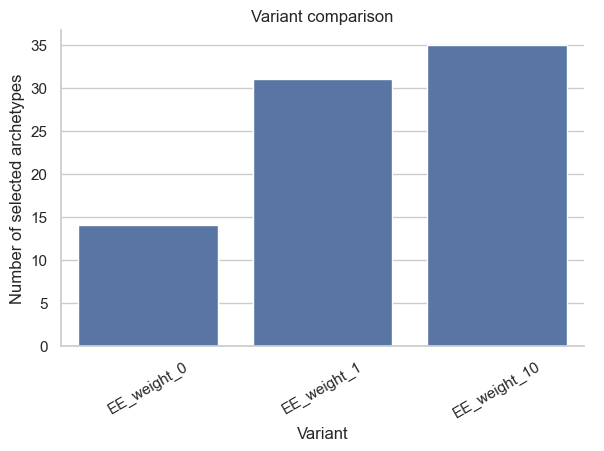

In [64]:

sns.catplot(
    data=variant_summary_df,
    x="variant",
    y="selected_archetypes",
    kind="bar",
    height=4,
    aspect=1.5,
)
plt.xlabel("Variant")
plt.ylabel("Number of selected archetypes")
plt.title("Variant comparison")
plt.xticks(rotation=30)



## 23. Export results

Exporting is useful for documentation, reporting, or checking results in Excel.


In [65]:

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

result.to_excel(OUTPUT_DIR / "building_sector_result.xlsx")
constraint_eval_df.to_excel(OUTPUT_DIR / "building_sector_constraint_evaluation.xlsx", index=False)
energy_summary_df.to_excel(OUTPUT_DIR / "building_sector_energy_summary.xlsx", index=False)

print("Exported files to:", OUTPUT_DIR.resolve())


Exported files to: C:\Users\schneids\code\building-archetype-inference\notebooks\outputs



## 24. Practical assignment workflow

Suggested workflow for students:

1. Open `constraints_sector_model.xlsx`.
2. Edit or extend the `NGF` and `EE` sheets.
3. Use empty filter cells intentionally: empty means “do not filter by this column”.
4. Use empty `target_column` for pure NFA targets.
5. Use a valid archetype column name in `target_column` for energy, emissions, or other specific indicators.
6. Re-run the notebook sections:
   - load constraints
   - rebuild constraints
   - solve
   - evaluate slacks
   - plot distributions
7. Document which constraints are well matched and which are violated.
8. Interpret the resulting sector composition: age, size, quality, energy supply, energy demand, and emissions.



## 25. Useful short snippets

Copy these into new cells as needed.


In [66]:

# Show all constraints currently stored in the BuildingSector object.
display(bs.list_constraints())


,name,type,filter,column,target,weight
0,Stat_AT_NGF_0,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,9.832290e+05,1000000
1,Stat_AT_NGF_1,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,3.919330e+05,1000000
2,Stat_AT_NGF_2,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,5.942340e+05,1000000
3,Stat_AT_NGF_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,6.294900e+05,1000000
4,Stat_AT_NGF_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,6.345030e+05,1000000
...,...,...,...,...,...,...
903,Stat_AT_EE_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10,1
904,Stat_AT_EE_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09,1
905,Stat_AT_EE_5,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09,1
906,Stat_AT_EE_6,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Warmwasser_Endenergiebedarf_kWh/m²NGFa,1.073889e+10,1


In [67]:

# Show selected archetypes only.
display(result[result["NFA"] > 0])


,Total Net floor Area,Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Geometry,m²NGF,Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,Bauperiode (Ebene +2),Building Quality,renovated,thermisch wirksame Speichermasse,...,WW Endenergiebedarf Elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW Hilfsstrom__,WW 1 Endenergie thermisch__kWh/m²NGFa,WW 1 Endenergie elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW 1 Hilfsstrom__kWh/m²NGFa,WW 2 Endenergie thermisch__kWh/m²NGFa,WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__kWh/m²NGFa,WW 2 Hilfsstrom__kWh/m²NGFa,buildings,NFA
ID,,,,,,,,,,,,,,,,,,,,,
140,NaN,Wohngebäude,MFHo,356.048,300 bis 500 Quadratmeter,bis 1944,Vor 1919,PH_3/3,1,mittel (124 Wh/m²K),...,0.798780,0.798780,15.975610,0.798780,0.798780,0,0,0,1.349422e+08,1.349422e+08
141,NaN,Wohngebäude,MFHo,356.048,300 bis 500 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,2.449158e+07,2.449158e+07
166,NaN,Wohngebäude,MFHk,356.048,300 bis 500 Quadratmeter,bis 1944,Vor 1919,OIB_1/3,1,mittel (124 Wh/m²K),...,7.988213,0.887530,17.750610,7.988213,0.887530,0,0,0,1.000000e+00,1.000000e+00
283,NaN,Wohngebäude,GWBg,1175.800,1000 Quadratmeter und mehr,bis 1944,Vor 1919,NEH_2/3,1,mittel (124 Wh/m²K),...,0.798780,0.798780,15.975610,0.798780,0.798780,0,0,0,9.280450e+08,9.280450e+08
321,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,1945 - 1989,1945 bis 1960,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,1.947727e+06,1.947727e+06
581,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,1990 - 1999,1991 bis 2000,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,1.644906e+06,1.644906e+06
582,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,1990 - 1999,1991 bis 2000,OIB_1/3,1,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,1.000000e+00,1.000000e+00
609,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,1990 - 1999,1991 bis 2000,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,1.000000e+00,1.000000e+00
632,NaN,Wohngebäude,EFHk,137.184,Unter 200 Quadratmeter,1990 - 1999,1991 bis 2000,PH_3/3,1,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,1.000000e+00,1.000000e+00


In [68]:

# Show the largest archetypes by NFA.
display(result.sort_values("NFA", ascending=False).head(20))


,Total Net floor Area,Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Geometry,m²NGF,Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,Bauperiode (Ebene +2),Building Quality,renovated,thermisch wirksame Speichermasse,...,WW Endenergiebedarf Elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW Hilfsstrom__,WW 1 Endenergie thermisch__kWh/m²NGFa,WW 1 Endenergie elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW 1 Hilfsstrom__kWh/m²NGFa,WW 2 Endenergie thermisch__kWh/m²NGFa,WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__kWh/m²NGFa,WW 2 Hilfsstrom__kWh/m²NGFa,buildings,NFA
ID,,,,,,,,,,,,,,,,,,,,,
1702,NaN,Wohngebäude,GWBg,1175.800,1000 Quadratmeter und mehr,bis 1944,1919 bis 1944,OIB_1/3,1,mittel (124 Wh/m²K),...,7.988241,0.887530,17.750610,7.988241,0.887530,0,0,0,1.225554e+09,1.225554e+09
283,NaN,Wohngebäude,GWBg,1175.800,1000 Quadratmeter und mehr,bis 1944,Vor 1919,NEH_2/3,1,mittel (124 Wh/m²K),...,0.798780,0.798780,15.975610,0.798780,0.798780,0,0,0,9.280450e+08,9.280450e+08
140,NaN,Wohngebäude,MFHo,356.048,300 bis 500 Quadratmeter,bis 1944,Vor 1919,PH_3/3,1,mittel (124 Wh/m²K),...,0.798780,0.798780,15.975610,0.798780,0.798780,0,0,0,1.349422e+08,1.349422e+08
1569,NaN,Wohngebäude,MFHo,356.048,300 bis 500 Quadratmeter,bis 1944,1919 bis 1944,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,5.124053e+07,5.124053e+07
1541,NaN,Wohngebäude,MFHo,356.048,300 bis 500 Quadratmeter,bis 1944,1919 bis 1944,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,2.997336e+07,2.997336e+07
141,NaN,Wohngebäude,MFHo,356.048,300 bis 500 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,2.449158e+07,2.449158e+07
2891,NaN,Andere Gebäude,DLG3k,1175.800,1 000 Quadratmeter und mehr,1979 - 2009,1991 bis 2000,original,0,mittel (124 Wh/m²K),...,0.169823,0.169823,3.396458,0.169823,0.169823,0,0,0,3.833012e+06,3.833012e+06
2885,NaN,Andere Gebäude,DLG3k,1175.800,1 000 Quadratmeter und mehr,bis 1978,1945 bis 1960,original,0,mittel (124 Wh/m²K),...,0.169823,0.169823,3.396458,0.169823,0.169823,0,0,0,2.496472e+06,2.496472e+06
2897,NaN,Andere Gebäude,DLG3k,1175.800,1 000 Quadratmeter und mehr,2010 - 2030,2011 und später,original,0,mittel (124 Wh/m²K),...,0.169823,0.169823,3.396458,0.169823,0.169823,0,0,0,2.398268e+06,2.398268e+06


In [69]:

# Calculate one weighted total manually.
example_col = energy_indicator_cols[0] if len(energy_indicator_cols) > 0 else None

if example_col is not None:
    total = (result["NFA"] * result[example_col]).sum()
    print(example_col, total)
else:
    print("No energy indicator available.")


Gas_Quartier_kWh/m²NGFa 17073093502.579956


In [70]:

# Remove one constraint family and solve again.
# Use with care: this changes bs.constraints.
# bs.remove_constraints("Stat_AT_EE")
# bs.solve(timeLimit=10)


In [71]:

# Clear all constraints and start again.
# Use with care: this removes all stored constraints.
# bs.clear_constraints()



## 26. Possible analysis questions

- How does adding EE constraints change the selected archetypes?
- Which construction periods are hardest to match?
- Do EE constraints create larger slacks than NGF constraints?
- Which energy supply systems dominate the optimized sector?
- How sensitive are results to the EE constraint weight?
- Which target columns produce implausible or impossible results?
- Which additional constraints would improve plausibility?
